# Main figures

Run the cells in order. Figures are saved to `output/figures` and plotting data to `output`.

## Setup

In [1]:
from pathlib import Path
import sys, os, shutil

cwd = Path.cwd()
candidates = [cwd, cwd / 'code', Path(globals().get('__file__', cwd / 'main_figures.ipynb')).resolve().parent]
CODE_ROOT = next((p for p in candidates if (p / 'paths.py').is_file()), None)
if CODE_ROOT is None:
    raise FileNotFoundError('Open this notebook from the project root or code directory.')
sys.path.insert(0, str(CODE_ROOT))
__file__ = str(CODE_ROOT / 'main_figures.ipynb')
from paths import DATA_ROOT, WORK, RESULTS, OUTPUT_ROOT

D = WORK / 'Source_Data'
Q = RESULTS / 'checks/figures'
O = RESULTS / 'figures'
for directory in [D, Q, O]:
    directory.mkdir(parents=True, exist_ok=True)
if not (D / 'scenario_parameters.csv').exists():
    shutil.copytree(DATA_ROOT / 'parameters', D, dirs_exist_ok=True)
    shutil.copy2(D / 'scenario_parameters_41.csv', D / 'scenario_parameters.csv')
os.environ.setdefault('MPLCONFIGDIR', str(WORK / 'matplotlib'))
import cartopy
cartopy.config['data_dir'] = DATA_ROOT / 'maps'

def show_figure(number):
    if 'get_ipython' in globals():
        from IPython.display import Image, display
        display(Image(filename=str(O / f'Figure_{number}.png')))


## Layout utilities

In [2]:
from __future__ import annotations
#!/usr/bin/env python3
"""Check subplot positions, sizes and spacing using rendered figure geometry."""


import argparse
import html
import json
import math
import os
import re
import tempfile
from collections import defaultdict
from collections.abc import Iterable, Mapping, Sequence
from pathlib import Path
from typing import Any


SCHEMA_VERSION = 1
DEFAULT_TOLERANCE_PT = 1.5
DEFAULT_GUTTER_TOLERANCE_PT = 1.5


class PanelAlignmentError(RuntimeError):
    """Raised when a required in-memory alignment gate does not pass."""


def _atomic_write_text(path: Path, content: str) -> None:
    path.parent.mkdir(parents=True, exist_ok=True)
    descriptor, temporary_name = tempfile.mkstemp(
        prefix=f".{path.name}.", suffix=".tmp", dir=path.parent
    )
    temporary = Path(temporary_name)
    try:
        with os.fdopen(descriptor, "w", encoding="utf-8") as handle:
            handle.write(content)
        temporary.replace(path)
    except Exception:
        temporary.unlink(missing_ok=True)
        raise


def _bbox(value: Any) -> tuple[float, float, float, float]:
    if isinstance(value, Mapping):
        values = [value.get(key) for key in ("left", "bottom", "right", "top")]
    else:
        values = list(value) if isinstance(value, Sequence) else []
    if len(values) != 4:
        raise ValueError("panel bbox_pt must contain left, bottom, right and top")
    bbox = tuple(float(item) for item in values)
    if not all(math.isfinite(item) for item in bbox):
        raise ValueError("panel bbox_pt values must be finite")
    if bbox[2] <= bbox[0] or bbox[3] <= bbox[1]:
        raise ValueError("panel bbox_pt must have positive width and height")
    return bbox


def _group_rows(raw: Any, prefix: str) -> list[dict[str, Any]]:
    groups: list[dict[str, Any]] = []
    if raw is None:
        return groups
    if not isinstance(raw, Sequence) or isinstance(raw, (str, bytes)):
        raise ValueError(f"{prefix}_groups must be a list")
    for index, item in enumerate(raw, 1):
        if isinstance(item, Mapping):
            panels = item.get("panels", [])
            group_id = str(item.get("id") or f"{prefix}-{index}")
        else:
            panels = item
            group_id = f"{prefix}-{index}"
        if not isinstance(panels, Sequence) or isinstance(panels, (str, bytes)):
            raise ValueError(f"{prefix} group {group_id} must list panel ids")
        panel_ids = [str(panel) for panel in panels]
        if len(panel_ids) < 2:
            raise ValueError(f"{prefix} group {group_id} needs at least two panels")
        if len(panel_ids) != len(set(panel_ids)):
            raise ValueError(f"{prefix} group {group_id} repeats a panel id")
        groups.append({"id": group_id, "panels": panel_ids})
    return groups


def _inferred_groups(panels: Sequence[dict[str, Any]], orientation: str) -> list[dict[str, Any]]:
    grouped: dict[tuple[Any, ...], list[str]] = defaultdict(list)
    for panel in panels:
        if orientation == "row":
            fields = (panel.get("grid_id"), panel.get("row_start"), panel.get("row_stop"))
        else:
            fields = (panel.get("grid_id"), panel.get("col_start"), panel.get("col_stop"))
        if any(value is None for value in fields):
            continue
        grouped[fields].append(str(panel["id"]))
    output: list[dict[str, Any]] = []
    for index, (_key, panel_ids) in enumerate(grouped.items(), 1):
        if len(panel_ids) >= 2:
            output.append({"id": f"inferred-{orientation}-{index}", "panels": panel_ids})
    return output


def _inferred_boundary_groups(panels: Sequence[dict[str, Any]]) -> list[dict[str, Any]]:
    """Infer shared grid boundaries across panels with unequal spans.

    This covers layouts such as two stacked panels beside one panel that spans
    both rows. Equal-span panels are handled by the ordinary row/column groups,
    so boundary groups are emitted only when at least two different spans meet
    at the same grid boundary.
    """
    specifications = (
        ("top", "row_start", "row_start", "row_stop"),
        ("bottom", "row_stop", "row_start", "row_stop"),
        ("left", "col_start", "col_start", "col_stop"),
        ("right", "col_stop", "col_start", "col_stop"),
    )
    output: list[dict[str, Any]] = []
    for edge, boundary_field, span_start, span_stop in specifications:
        grouped: dict[tuple[Any, Any], list[dict[str, Any]]] = defaultdict(list)
        for panel in panels:
            grid_id = panel.get("grid_id")
            boundary = panel.get(boundary_field)
            start = panel.get(span_start)
            stop = panel.get(span_stop)
            if any(value is None for value in (grid_id, boundary, start, stop)):
                continue
            grouped[(grid_id, boundary)].append(panel)
        edge_index = 0
        for (_grid_id, _boundary), members in grouped.items():
            spans = {(panel.get(span_start), panel.get(span_stop)) for panel in members}
            if len(members) < 2 or len(spans) < 2:
                continue
            edge_index += 1
            output.append(
                {
                    "id": f"inferred-shared-{edge}-{edge_index}",
                    "edge": edge,
                    "panels": [str(panel["id"]) for panel in members],
                }
            )
    return output


def _validated_layout(manifest: Mapping[str, Any]) -> tuple[dict[str, Any] | None, list[str]]:
    errors: list[str] = []
    if manifest.get("schema_version") != SCHEMA_VERSION:
        errors.append(f"schema_version must be {SCHEMA_VERSION}")

    figure = manifest.get("figure")
    if not isinstance(figure, Mapping):
        errors.append("figure must be an object with width_pt and height_pt")
        figure = {}
    try:
        width_pt = float(figure.get("width_pt"))
        height_pt = float(figure.get("height_pt"))
        if not math.isfinite(width_pt) or not math.isfinite(height_pt) or width_pt <= 0 or height_pt <= 0:
            raise ValueError
    except (TypeError, ValueError):
        errors.append("figure width_pt and height_pt must be positive finite numbers")
        width_pt = height_pt = 0.0

    raw_panels = manifest.get("panels")
    panels: list[dict[str, Any]] = []
    if not isinstance(raw_panels, Sequence) or isinstance(raw_panels, (str, bytes)):
        errors.append("panels must be a list")
        raw_panels = []
    for index, raw_panel in enumerate(raw_panels, 1):
        if not isinstance(raw_panel, Mapping):
            errors.append(f"panel {index} must be an object")
            continue
        panel_id = str(raw_panel.get("id") or "").strip()
        if not panel_id:
            errors.append(f"panel {index} is missing id")
            continue
        try:
            bbox = _bbox(raw_panel.get("bbox_pt"))
        except (TypeError, ValueError) as exc:
            errors.append(f"panel {panel_id}: {exc}")
            continue
        if bbox[0] < -0.01 or bbox[1] < -0.01 or bbox[2] > width_pt + 0.01 or bbox[3] > height_pt + 0.01:
            errors.append(f"panel {panel_id} bbox_pt extends beyond the declared figure")
        panel = dict(raw_panel)
        panel["id"] = panel_id
        panel["bbox_pt"] = list(bbox)
        anchor = raw_panel.get("panel_label_anchor_pt")
        if anchor is not None:
            try:
                anchor_values = [float(value) for value in anchor]
                if len(anchor_values) != 2 or not all(math.isfinite(value) for value in anchor_values):
                    raise ValueError
                panel["panel_label_anchor_pt"] = anchor_values
            except (TypeError, ValueError):
                errors.append(f"panel {panel_id} has invalid panel_label_anchor_pt")
        panels.append(panel)

    panel_ids = [panel["id"] for panel in panels]
    if len(panel_ids) != len(set(panel_ids)):
        errors.append("panel ids must be unique")
    if not panels:
        errors.append("at least one panel rectangle is required")

    try:
        row_groups = _group_rows(manifest.get("row_groups"), "row")
        column_groups = _group_rows(manifest.get("column_groups"), "column")
    except ValueError as exc:
        errors.append(str(exc))
        row_groups = column_groups = []
    if not row_groups:
        row_groups = _inferred_groups(panels, "row")
    if not column_groups:
        column_groups = _inferred_groups(panels, "column")
    boundary_groups = _inferred_boundary_groups(panels)

    known_ids = set(panel_ids)
    for group in [*row_groups, *column_groups]:
        missing = [panel for panel in group["panels"] if panel not in known_ids]
        if missing:
            errors.append(f"group {group['id']} references unknown panels: {', '.join(missing)}")

    exemptions: list[dict[str, Any]] = []
    raw_exemptions = manifest.get("exemptions", [])
    if not isinstance(raw_exemptions, Sequence) or isinstance(raw_exemptions, (str, bytes)):
        errors.append("exemptions must be a list")
        raw_exemptions = []
    for index, exemption in enumerate(raw_exemptions, 1):
        if not isinstance(exemption, Mapping):
            errors.append(f"exemption {index} must be an object")
            continue
        exemption_panels = exemption.get("panels", [])
        checks = exemption.get("checks", [])
        reason = str(exemption.get("reason") or "").strip()
        if isinstance(exemption_panels, str):
            exemption_panels = [exemption_panels]
        if isinstance(checks, str):
            checks = [checks]
        if not exemption_panels or any(str(panel) not in known_ids for panel in exemption_panels):
            errors.append(f"exemption {index} must reference known panels")
        allowed_checks = {
            "row",
            "column",
            "panel-width",
            "horizontal-gutter",
            "vertical-gutter",
            "panel-label",
            "all",
        }
        check_names = [str(check) for check in checks]
        if not check_names or any(check not in allowed_checks for check in check_names):
            errors.append(f"exemption {index} has invalid checks")
        if not reason:
            errors.append(f"exemption {index} needs a non-empty reason")
        exemptions.append(
            {"panels": [str(panel) for panel in exemption_panels], "checks": check_names, "reason": reason}
        )

    if errors:
        return None, errors
    return {
        "schema_version": SCHEMA_VERSION,
        "backend": str(manifest.get("backend") or "unknown"),
        "figure": {"width_pt": width_pt, "height_pt": height_pt},
        "panels": panels,
        "row_groups": row_groups,
        "column_groups": column_groups,
        "boundary_groups": boundary_groups,
        "exemptions": exemptions,
    }, []


def _is_exempt(layout: Mapping[str, Any], panel_id: str, check: str) -> bool:
    for exemption in layout.get("exemptions", []):
        if panel_id in exemption["panels"] and (check in exemption["checks"] or "all" in exemption["checks"]):
            return True
    return False


def _metric_spread(values: Mapping[str, float]) -> float:
    return max(values.values()) - min(values.values()) if values else 0.0


def _finding(
    kind: str,
    group: Mapping[str, Any],
    panels: Sequence[str],
    tolerance_pt: float,
    metrics: Mapping[str, Mapping[str, float]],
    message: str,
    severity: str = "FAIL",
) -> dict[str, Any]:
    return {
        "severity": severity,
        "kind": kind,
        "group": group["id"],
        "panels": list(panels),
        "message": message,
        "tolerance_pt": tolerance_pt,
        "metric_spreads_pt": {
            metric: round(_metric_spread(values), 6) for metric, values in metrics.items()
        },
        "values_pt": {
            metric: {panel: round(value, 6) for panel, value in values.items()}
            for metric, values in metrics.items()
        },
    }


def audit_layout_manifest(
    manifest: Mapping[str, Any],
    *,
    tolerance_pt: float = DEFAULT_TOLERANCE_PT,
    gutter_tolerance_pt: float = DEFAULT_GUTTER_TOLERANCE_PT,
    require_panel_labels: bool = False,
) -> dict[str, Any]:
    """Audit a backend-neutral panel-layout manifest."""
    if tolerance_pt < 0 or gutter_tolerance_pt < 0:
        raise ValueError("alignment tolerances must be non-negative")
    layout, errors = _validated_layout(manifest)
    if layout is None:
        return {
            "schema_version": SCHEMA_VERSION,
            "auditable": False,
            "verdict": "NOT AUDITABLE",
            "summary": {"fail": 0, "warn": 0, "comparisons": 0, "exemptions": 0},
            "errors": errors,
            "findings": [],
        }

    if len(layout["panels"]) == 1:
        return {
            "schema_version": SCHEMA_VERSION,
            "applicable": False,
            "auditable": False,
            "verdict": "NOT APPLICABLE",
            "backend": layout["backend"],
            "summary": {"fail": 0, "warn": 0, "comparisons": 0, "exemptions": 0},
            "tolerances": {
                "alignment_pt": tolerance_pt,
                "gutter_pt": gutter_tolerance_pt,
            },
            "errors": [],
            "findings": [],
            "layout": layout,
        }

    panel_map = {panel["id"]: panel for panel in layout["panels"]}
    findings: list[dict[str, Any]] = []
    comparisons = 0

    for orientation, group_key, check_name in (
        ("row", "row_groups", "row"),
        ("column", "column_groups", "column"),
    ):
        for group in layout[group_key]:
            group_panel_ids = list(group["panels"])
            panel_ids = [
                panel_id for panel_id in group_panel_ids if not _is_exempt(layout, panel_id, check_name)
            ]
            if len(panel_ids) < 2:
                continue
            comparisons += 1
            boxes = {panel_id: _bbox(panel_map[panel_id]["bbox_pt"]) for panel_id in panel_ids}
            if orientation == "row":
                metrics = {
                    "top": {panel: box[3] for panel, box in boxes.items()},
                    "bottom": {panel: box[1] for panel, box in boxes.items()},
                    "height": {panel: box[3] - box[1] for panel, box in boxes.items()},
                }
                kind = "row-axes-misalignment"
                message = "Panels intended for one row do not share top/bottom edges and height"
            else:
                metrics = {
                    "left": {panel: box[0] for panel, box in boxes.items()},
                    "right": {panel: box[2] for panel, box in boxes.items()},
                    "width": {panel: box[2] - box[0] for panel, box in boxes.items()},
                }
                kind = "column-axes-misalignment"
                message = "Panels intended for one column do not share left/right edges and width"
            if max(_metric_spread(values) for values in metrics.values()) > tolerance_pt:
                findings.append(_finding(kind, group, panel_ids, tolerance_pt, metrics, message))

            if orientation == "row" and len(group_panel_ids) >= 3:
                width_candidates = [
                    panel_id
                    for panel_id in group_panel_ids
                    if not _is_exempt(layout, panel_id, "row")
                    and not _is_exempt(layout, panel_id, "panel-width")
                ]
                by_column_span: dict[Any, list[str]] = defaultdict(list)
                for panel_id in width_candidates:
                    panel = panel_map[panel_id]
                    try:
                        column_span = float(panel.get("col_stop")) - float(panel.get("col_start"))
                        if not math.isfinite(column_span) or column_span <= 0:
                            raise ValueError
                        span_key: Any = round(column_span, 9)
                    except (TypeError, ValueError):
                        span_key = "unspecified"
                    by_column_span[span_key].append(panel_id)
                for width_index, width_ids in enumerate(by_column_span.values(), 1):
                    if len(width_ids) < 2:
                        continue
                    comparisons += 1
                    width_metrics = {
                        "width": {
                            panel_id: _bbox(panel_map[panel_id]["bbox_pt"])[2]
                            - _bbox(panel_map[panel_id]["bbox_pt"])[0]
                            for panel_id in width_ids
                        }
                    }
                    if _metric_spread(width_metrics["width"]) > tolerance_pt:
                        findings.append(
                            _finding(
                                "horizontal-panel-width-misalignment",
                                {"id": f"{group['id']}-equal-span-{width_index}"},
                                width_ids,
                                tolerance_pt,
                                width_metrics,
                                "Three-or-more-panel row contains unequal final plot-area widths for equal grid spans",
                            )
                        )

            anchors = {
                panel_id: panel_map[panel_id].get("panel_label_anchor_pt") for panel_id in panel_ids
            }
            present_anchors = {panel: anchor for panel, anchor in anchors.items() if anchor is not None}
            missing_labels = [panel for panel, anchor in anchors.items() if anchor is None]
            if require_panel_labels and missing_labels:
                findings.append(
                    {
                        "severity": "WARN",
                        "kind": "panel-label-not-auditable",
                        "group": group["id"],
                        "panels": missing_labels,
                        "message": "Comparable panels are missing detectable top-left panel-label anchors",
                    }
                )
            if len(present_anchors) >= 2:
                label_check = "panel-label"
                label_ids = [
                    panel for panel in panel_ids if panel in present_anchors and not _is_exempt(layout, panel, label_check)
                ]
                if len(label_ids) >= 2:
                    coordinate = 1 if orientation == "row" else 0
                    metric_name = "label-y" if orientation == "row" else "label-x"
                    metrics = {
                        metric_name: {panel: float(present_anchors[panel][coordinate]) for panel in label_ids}
                    }
                    if _metric_spread(metrics[metric_name]) > tolerance_pt:
                        findings.append(
                            _finding(
                                f"{orientation}-panel-label-misalignment",
                                group,
                                label_ids,
                                tolerance_pt,
                                metrics,
                                "Panel-label anchors are not aligned within their comparable group",
                            )
                        )

            gutter_check = "horizontal-gutter" if orientation == "row" else "vertical-gutter"
            gutter_ids = [panel for panel in panel_ids if not _is_exempt(layout, panel, gutter_check)]
            if len(gutter_ids) >= 2:
                if orientation == "row":
                    ordered = sorted(gutter_ids, key=lambda panel: boxes[panel][0])
                    gaps = {
                        f"{first}->{second}": boxes[second][0] - boxes[first][2]
                        for first, second in zip(ordered, ordered[1:])
                    }
                else:
                    ordered = sorted(gutter_ids, key=lambda panel: boxes[panel][3], reverse=True)
                    gaps = {
                        f"{first}->{second}": boxes[first][1] - boxes[second][3]
                        for first, second in zip(ordered, ordered[1:])
                    }
                if gaps and min(gaps.values()) < -tolerance_pt:
                    findings.append(
                        _finding(
                            "panel-axes-overlap",
                            group,
                            gutter_ids,
                            tolerance_pt,
                            {"gutter": gaps},
                            "Panel plot-area rectangles overlap",
                        )
                    )
                elif len(gaps) >= 2 and _metric_spread(gaps) > gutter_tolerance_pt:
                    findings.append(
                        _finding(
                            f"{gutter_check}-misalignment",
                            group,
                            gutter_ids,
                            gutter_tolerance_pt,
                            {"gutter": gaps},
                            "Comparable inter-panel gutters are not uniform",
                        )
                    )

    edge_coordinates = {"left": 0, "bottom": 1, "right": 2, "top": 3}
    for group in layout["boundary_groups"]:
        edge = str(group["edge"])
        check_name = "row" if edge in {"top", "bottom"} else "column"
        panel_ids = [
            panel_id
            for panel_id in group["panels"]
            if not _is_exempt(layout, panel_id, check_name)
        ]
        if len(panel_ids) < 2:
            continue
        comparisons += 1
        coordinate = edge_coordinates[edge]
        metrics = {
            edge: {
                panel_id: _bbox(panel_map[panel_id]["bbox_pt"])[coordinate]
                for panel_id in panel_ids
            }
        }
        if _metric_spread(metrics[edge]) > tolerance_pt:
            findings.append(
                _finding(
                    f"shared-{edge}-edge-misalignment",
                    group,
                    panel_ids,
                    tolerance_pt,
                    metrics,
                    f"Panels meeting the same grid {edge} boundary are not aligned",
                )
            )

        if edge not in {"top", "left"}:
            continue
        anchors = {
            panel_id: panel_map[panel_id].get("panel_label_anchor_pt")
            for panel_id in panel_ids
        }
        missing_labels = [panel_id for panel_id, anchor in anchors.items() if anchor is None]
        if require_panel_labels and missing_labels:
            findings.append(
                {
                    "severity": "WARN",
                    "kind": "panel-label-not-auditable",
                    "group": group["id"],
                    "panels": missing_labels,
                    "message": "Comparable panels are missing detectable top-left panel-label anchors",
                }
            )
        label_ids = [
            panel_id
            for panel_id, anchor in anchors.items()
            if anchor is not None and not _is_exempt(layout, panel_id, "panel-label")
        ]
        if len(label_ids) < 2:
            continue
        label_coordinate = 1 if edge == "top" else 0
        metric_name = "label-y" if edge == "top" else "label-x"
        label_metrics = {
            metric_name: {
                panel_id: float(anchors[panel_id][label_coordinate])
                for panel_id in label_ids
            }
        }
        if _metric_spread(label_metrics[metric_name]) > tolerance_pt:
            findings.append(
                _finding(
                    f"shared-{edge}-panel-label-misalignment",
                    group,
                    label_ids,
                    tolerance_pt,
                    label_metrics,
                    "Panel-label anchors are not aligned at the shared grid boundary",
                )
            )
    fail_count = sum(finding["severity"] == "FAIL" for finding in findings)
    warn_count = sum(finding["severity"] == "WARN" for finding in findings)
    auditable = comparisons > 0
    verdict = "FIX BEFORE DELIVERY" if fail_count else "REVIEW REQUIRED" if warn_count else "PASS"
    if not auditable:
        verdict = "NOT AUDITABLE"
    return {
        "schema_version": SCHEMA_VERSION,
        "applicable": True,
        "auditable": auditable,
        "verdict": verdict,
        "backend": layout["backend"],
        "summary": {
            "fail": fail_count,
            "warn": warn_count,
            "comparisons": comparisons,
            "exemptions": len(layout["exemptions"]),
        },
        "tolerances": {
            "alignment_pt": tolerance_pt,
            "gutter_pt": gutter_tolerance_pt,
        },
        "layout": layout,
        "findings": findings,
        **(
            {"errors": ["No comparable row, column or shared-boundary groups were declared or inferred"]}
            if not auditable
            else {}
        ),
    }


def exit_code(report: Mapping[str, Any], strict: bool = False) -> int:
    if report.get("verdict") == "NOT APPLICABLE":
        return 0
    if not report.get("auditable") or report.get("verdict") == "NOT AUDITABLE":
        return 2
    if int(report.get("summary", {}).get("fail", 0)):
        return 1
    if strict and int(report.get("summary", {}).get("warn", 0)):
        return 1
    return 0


def render_text(report: Mapping[str, Any], strict: bool = False) -> str:
    summary = report.get("summary", {})
    lines = [
        f"Panel alignment: {report.get('verdict', 'UNKNOWN')}",
        f"  comparisons: {summary.get('comparisons', 0)}",
        f"  fail: {summary.get('fail', 0)}",
        f"  warn: {summary.get('warn', 0)}",
        f"  exemptions: {summary.get('exemptions', 0)}",
    ]
    for error in report.get("errors", []):
        lines.append(f"  ERROR: {error}")
    for finding in report.get("findings", []):
        lines.append(
            f"  {finding['severity']} {finding['kind']} [{finding.get('group', 'n/a')}]: "
            f"{finding['message']} ({', '.join(finding.get('panels', []))})"
        )
    if strict and summary.get("warn", 0):
        lines.append("  strict mode: WARN findings block delivery")
    return "\n".join(lines)


def write_json_report(report: Mapping[str, Any], path: str | Path) -> None:
    _atomic_write_text(Path(path), json.dumps(report, indent=2, ensure_ascii=False) + "\n")


def write_overlay_svg(report: Mapping[str, Any], path: str | Path) -> None:
    layout = report.get("layout")
    if not isinstance(layout, Mapping):
        raise ValueError("an auditable layout is required for the diagnostic SVG")
    width = float(layout["figure"]["width_pt"])
    height = float(layout["figure"]["height_pt"])
    failed_panels = {
        panel for finding in report.get("findings", []) if finding.get("severity") == "FAIL"
        for panel in finding.get("panels", [])
    }
    rows = [
        f'<svg xmlns="http://www.w3.org/2000/svg" width="{width}pt" height="{height}pt" viewBox="0 0 {width} {height}">',
        '<rect width="100%" height="100%" fill="white"/>',
    ]
    for panel in layout["panels"]:
        left, bottom, right, top = _bbox(panel["bbox_pt"])
        y = height - top
        color = "#d7191c" if panel["id"] in failed_panels else "#2c7bb6"
        rows.append(
            f'<rect x="{left:.3f}" y="{y:.3f}" width="{right-left:.3f}" height="{top-bottom:.3f}" '
            f'fill="none" stroke="{color}" stroke-width="1.2"/>'
        )
        rows.append(
            f'<text x="{left+2:.3f}" y="{y+10:.3f}" font-family="Arial, sans-serif" font-size="8" '
            f'fill="{color}">{html.escape(str(panel["id"]))}</text>'
        )
    rows.append(
        f'<text x="4" y="{height-5:.3f}" font-family="Arial, sans-serif" font-size="7" fill="#333">'
        f'{report.get("verdict", "UNKNOWN")}: {report.get("summary", {}).get("fail", 0)} fail, '
        f'{report.get("summary", {}).get("warn", 0)} warn</text>'
    )
    rows.append("</svg>")
    _atomic_write_text(Path(path), "\n".join(rows) + "\n")


def _alphabetic_id(index: int) -> str:
    output = ""
    value = index + 1
    while value:
        value, remainder = divmod(value - 1, 26)
        output = chr(ord("a") + remainder) + output
    return output


def _font_is_bold(weight: Any) -> bool:
    if isinstance(weight, (int, float)):
        return float(weight) >= 600
    return str(weight).lower() in {"bold", "semibold", "demibold", "heavy", "black"}


def _matplotlib_panel_label_anchor(ax: Any) -> tuple[str, list[float]] | None:
    for artist in ax.texts:
        label = artist.get_text().strip()
        if not re.fullmatch(r"[a-z]", label) or not _font_is_bold(artist.get_fontweight()):
            continue
        display = artist.get_transform().transform(artist.get_position())
        axes_xy = ax.transAxes.inverted().transform(display)
        if not (-0.35 <= axes_xy[0] <= 0.2 and 0.8 <= axes_xy[1] <= 1.35):
            continue
        inches = ax.figure.dpi_scale_trans.inverted().transform(display)
        return label, [float(inches[0] * 72), float(inches[1] * 72)]
    return None


def matplotlib_layout_manifest(
    fig: Any,
    *,
    axes: Sequence[Any] | None = None,
    panel_ids: Mapping[Any, str] | Sequence[str] | None = None,
    row_groups: Sequence[Any] | None = None,
    column_groups: Sequence[Any] | None = None,
    exclude_axes: Iterable[Any] = (),
    exemptions: Sequence[Mapping[str, Any]] = (),
) -> dict[str, Any]:
    """Measure final Matplotlib axes rectangles in physical points."""
    fig.canvas.draw()
    width_in, height_in = (float(value) for value in fig.get_size_inches())
    width_pt, height_pt = width_in * 72, height_in * 72
    excluded = {id(axis) for axis in exclude_axes}
    candidates = list(axes) if axes is not None else list(fig.axes)
    selected: list[Any] = []
    seen_subplot_cells: set[tuple[int, int, int]] = set()
    for axis in candidates:
        if id(axis) in excluded or not axis.get_visible():
            continue
        axis_label = str(axis.get_label() or "")
        if axis_label.startswith("<colorbar"):
            continue
        try:
            subplot_spec = axis.get_subplotspec()
        except AttributeError:
            subplot_spec = None
        if subplot_spec is not None and panel_ids is None:
            subplot_key = (
                id(subplot_spec.get_gridspec()),
                int(subplot_spec.num1),
                int(subplot_spec.num2),
            )
            if subplot_key in seen_subplot_cells:
                continue
            seen_subplot_cells.add(subplot_key)
        selected.append(axis)

    if isinstance(panel_ids, Mapping):
        ids = [str(panel_ids.get(axis) or "") for axis in selected]
    elif panel_ids is not None:
        ids = [str(value) for value in panel_ids]
        if len(ids) != len(selected):
            raise ValueError("panel_ids length must match the selected Matplotlib axes")
    else:
        ids = []
        for index, axis in enumerate(selected):
            candidate = str(axis.get_gid() or axis.get_label() or "").strip()
            ids.append(candidate if candidate and not candidate.startswith("<") else _alphabetic_id(index))

    grid_ids: dict[int, str] = {}
    panels: list[dict[str, Any]] = []
    for axis, panel_id in zip(selected, ids):
        position = axis.get_position(original=False)
        panel: dict[str, Any] = {
            "id": panel_id,
            "bbox_pt": [
                float(position.x0 * width_pt),
                float(position.y0 * height_pt),
                float(position.x1 * width_pt),
                float(position.y1 * height_pt),
            ],
        }
        try:
            subplot_spec = axis.get_subplotspec()
        except AttributeError:
            subplot_spec = None
        if subplot_spec is not None:
            grid_spec = subplot_spec.get_gridspec()
            grid_key = id(grid_spec)
            if grid_key not in grid_ids:
                grid_ids[grid_key] = f"matplotlib-grid-{len(grid_ids) + 1}"
            panel.update(
                {
                    "grid_id": grid_ids[grid_key],
                    "row_start": int(subplot_spec.rowspan.start),
                    "row_stop": int(subplot_spec.rowspan.stop),
                    "col_start": int(subplot_spec.colspan.start),
                    "col_stop": int(subplot_spec.colspan.stop),
                }
            )
        label_anchor = _matplotlib_panel_label_anchor(axis)
        if label_anchor is not None:
            panel["panel_label"] = label_anchor[0]
            panel["panel_label_anchor_pt"] = label_anchor[1]
        panels.append(panel)

    manifest: dict[str, Any] = {
        "schema_version": SCHEMA_VERSION,
        "backend": "python-matplotlib",
        "figure": {"width_pt": width_pt, "height_pt": height_pt},
        "panels": panels,
        "exemptions": [dict(exemption) for exemption in exemptions],
    }
    if row_groups is not None:
        manifest["row_groups"] = list(row_groups)
    if column_groups is not None:
        manifest["column_groups"] = list(column_groups)
    return manifest


def require_matplotlib_panel_alignment(
    fig: Any,
    *,
    json_out: str | Path | None = None,
    overlay_svg: str | Path | None = None,
    tolerance_pt: float = DEFAULT_TOLERANCE_PT,
    gutter_tolerance_pt: float = DEFAULT_GUTTER_TOLERANCE_PT,
    require_panel_labels: bool = False,
    strict: bool = False,
    **manifest_options: Any,
) -> dict[str, Any]:
    """Measure and block delivery when a Matplotlib multi-panel layout is misaligned."""
    manifest = matplotlib_layout_manifest(fig, **manifest_options)
    report = audit_layout_manifest(
        manifest,
        tolerance_pt=tolerance_pt,
        gutter_tolerance_pt=gutter_tolerance_pt,
        require_panel_labels=require_panel_labels,
    )
    if json_out is not None:
        write_json_report(report, json_out)
    if overlay_svg is not None and report.get("layout"):
        write_overlay_svg(report, overlay_svg)
    code = exit_code(report, strict=strict)
    if code:
        raise PanelAlignmentError(render_text(report, strict=strict))
    return report


def run_self_tests() -> None:
    aligned = {
        "schema_version": 1,
        "backend": "self-test",
        "figure": {"width_pt": 300, "height_pt": 200},
        "panels": [
            {"id": "a", "bbox_pt": [20, 110, 130, 180], "grid_id": "g", "row_start": 0, "row_stop": 1, "col_start": 0, "col_stop": 1},
            {"id": "b", "bbox_pt": [170, 110, 280, 180], "grid_id": "g", "row_start": 0, "row_stop": 1, "col_start": 1, "col_stop": 2},
            {"id": "c", "bbox_pt": [20, 20, 130, 90], "grid_id": "g", "row_start": 1, "row_stop": 2, "col_start": 0, "col_stop": 1},
            {"id": "d", "bbox_pt": [170, 20, 280, 90], "grid_id": "g", "row_start": 1, "row_stop": 2, "col_start": 1, "col_stop": 2},
        ],
    }
    if exit_code(audit_layout_manifest(aligned)) != 0:
        raise AssertionError("aligned self-test layout did not pass")
    shifted = json.loads(json.dumps(aligned))
    shifted["panels"][1]["bbox_pt"][1] -= 5
    if exit_code(audit_layout_manifest(shifted)) != 1:
        raise AssertionError("shifted self-test layout did not fail")
    unequal_widths = {
        "schema_version": 1,
        "backend": "self-test",
        "figure": {"width_pt": 320, "height_pt": 100},
        "panels": [
            {"id": "a", "bbox_pt": [10, 20, 70, 80], "grid_id": "g", "row_start": 0, "row_stop": 1, "col_start": 0, "col_stop": 1},
            {"id": "b", "bbox_pt": [90, 20, 170, 80], "grid_id": "g", "row_start": 0, "row_stop": 1, "col_start": 1, "col_stop": 2},
            {"id": "c", "bbox_pt": [190, 20, 290, 80], "grid_id": "g", "row_start": 0, "row_stop": 1, "col_start": 2, "col_stop": 3},
        ],
    }
    unequal_report = audit_layout_manifest(unequal_widths)
    if exit_code(unequal_report) != 1 or not any(
        finding.get("kind") == "horizontal-panel-width-misalignment"
        for finding in unequal_report.get("findings", [])
    ):
        raise AssertionError("unequal-width self-test row did not fail")


def build_parser() -> argparse.ArgumentParser:
    parser = argparse.ArgumentParser(
        description="Audit rendered multi-panel axes alignment from a JSON layout manifest."
    )
    parser.add_argument("layout", nargs="?", help="backend-neutral panel-layout JSON")
    parser.add_argument("--json", action="store_true", help="print the report as JSON")
    parser.add_argument("--json-out", help="write the report atomically as JSON")
    parser.add_argument("--overlay-svg", help="write a QA-only SVG of measured panel rectangles")
    parser.add_argument("--tolerance-pt", type=float, default=DEFAULT_TOLERANCE_PT)
    parser.add_argument("--gutter-tolerance-pt", type=float, default=DEFAULT_GUTTER_TOLERANCE_PT)
    parser.add_argument("--require-panel-labels", action="store_true")
    parser.add_argument("--strict", action="store_true", help="make WARN findings blocking")
    parser.add_argument("--self-test", action="store_true", help="run dependency-free core tests")
    return parser


def main(argv: Sequence[str] | None = None) -> int:
    parser = build_parser()
    args = parser.parse_args(argv)
    if args.self_test:
        run_self_tests()
        print("Panel alignment self-test: PASS")
        return 0
    if not args.layout:
        parser.error("layout JSON is required unless --self-test is used")
    try:
        manifest = json.loads(Path(args.layout).read_text(encoding="utf-8"))
        report = audit_layout_manifest(
            manifest,
            tolerance_pt=args.tolerance_pt,
            gutter_tolerance_pt=args.gutter_tolerance_pt,
            require_panel_labels=args.require_panel_labels,
        )
    except (OSError, json.JSONDecodeError, TypeError, ValueError) as exc:
        report = {
            "schema_version": SCHEMA_VERSION,
            "auditable": False,
            "verdict": "NOT AUDITABLE",
            "summary": {"fail": 0, "warn": 0, "comparisons": 0, "exemptions": 0},
            "errors": [str(exc)],
            "findings": [],
        }
    if args.json_out:
        write_json_report(report, args.json_out)
    if args.overlay_svg and report.get("layout"):
        write_overlay_svg(report, args.overlay_svg)
    print(json.dumps(report, indent=2, ensure_ascii=False) if args.json else render_text(report, strict=args.strict))
    return exit_code(report, strict=args.strict)




## Plot style

In [3]:
"""Unified visual design system for PV_WRF figures.

Defines color palette, typography, and helper styling functions so every
publication-grade figure uses the same visual language.
"""

import matplotlib as mpl
import matplotlib.pyplot as plt


# ---- Color palette: muted, modern, climate-zone aware ----
PALETTE = {
    # Climate zones (used in city scatter + small multiples)
    "humid_continental_temperate": "#457b9d",  # slate blue
    "humid_subtropical_dense":     "#a8dadc",  # pale cyan
    "tropical_wet_dense":          "#2a9d8f",  # jade
    "hot_arid_dense_riverine":     "#f4a261",  # warm tan
    "hot_arid_low_density":        "#e76f51",  # terracotta
    "hot_arid_sparse":             "#e9c46a",  # amber

    # Channels (signed: cooling/ac/battery = negatives; roof = positive)
    "channel_cooling":   "#e63946",  # vermillion (negative)
    "channel_ac_eq":     "#f1a208",  # warm yellow
    "channel_roof":      "#06a77d",  # forest green (positive credit)
    "channel_battery":   "#8e44ad",  # deep violet
    "channel_net":       "#264653",  # dark teal

    # Diverging
    "carbon_saved":    "#06a77d",
    "feedback_neg":    "#e63946",
    "neutral":         "#dee2e6",

    # Map
    "land":   "#ededed",
    "ocean":  "#f5f7fa",
    "coast":  "#bdbdbd",

    # Text / lines
    "ink":           "#1d3557",
    "ink_light":     "#5a6478",
    "grid":          "#e3e6ea",
}

ZONE_LABELS = {
    "humid_continental_temperate":  "Humid continental",
    "humid_subtropical_dense":      "Humid subtropical",
    "tropical_wet_dense":           "Tropical wet",
    "hot_arid_dense_riverine":      "Hot arid (dense)",
    "hot_arid_low_density":         "Hot arid (sparse)",
    "hot_arid_sparse":              "Hot arid (very sparse)",
}


def apply_style() -> None:
    """Apply the global matplotlib styling — call once before drawing."""
    mpl.rcParams.update({
        "font.family":        "sans-serif",
        "font.sans-serif":    ["Segoe UI", "Helvetica", "Arial", "DejaVu Sans"],
        "font.size":          10,
        "font.weight":        400,
        "axes.titlesize":     11,
        "axes.titleweight":   600,
        "axes.titlepad":      10,
        "axes.labelsize":     9.5,
        "axes.labelweight":   500,
        "axes.labelcolor":    PALETTE["ink"],
        "axes.edgecolor":     PALETTE["ink_light"],
        "axes.linewidth":     0.6,
        "axes.spines.top":    False,
        "axes.spines.right":  False,
        "axes.grid":          False,
        "grid.color":         PALETTE["grid"],
        "grid.linewidth":     0.5,
        "grid.linestyle":     "-",
        "xtick.color":        PALETTE["ink_light"],
        "ytick.color":        PALETTE["ink_light"],
        "xtick.labelsize":    8.5,
        "ytick.labelsize":    8.5,
        "xtick.major.width":  0.6,
        "ytick.major.width":  0.6,
        "xtick.major.size":   3,
        "ytick.major.size":   3,
        "legend.frameon":     False,
        "legend.fontsize":    8,
        "legend.title_fontsize": 9,
        "figure.facecolor":   "white",
        "axes.facecolor":     "white",
        "savefig.facecolor":  "white",
        "savefig.dpi":        160,
        "savefig.bbox":       "tight",
    })


def style_axis(ax: plt.Axes, title: str | None = None,
               xlabel: str | None = None, ylabel: str | None = None) -> None:
    """Apply per-axis trim: no top/right spines, no grid, optional labels."""
    if title:
        ax.set_title(title, color=PALETTE["ink"], loc="left", pad=8)
    if xlabel:
        ax.set_xlabel(xlabel)
    if ylabel:
        ax.set_ylabel(ylabel)
    ax.tick_params(direction="out", length=3)
    for spine in ("top", "right"):
        ax.spines[spine].set_visible(False)
    for spine in ("left", "bottom"):
        ax.spines[spine].set_color(PALETTE["ink_light"])
        ax.spines[spine].set_linewidth(0.6)
    ax.grid(False)
    ax.set_axisbelow(True)


def annotate_pill(ax: plt.Axes, x, y, text: str, color: str | None = None) -> None:
    """Pill-shaped annotation badge for key numbers."""
    color = color or PALETTE["ink"]
    ax.annotate(
        text, xy=(x, y), xytext=(0, 14), textcoords="offset points",
        ha="center", va="bottom", fontsize=8, color="white", weight=600,
        bbox=dict(boxstyle="round,pad=0.4", facecolor=color, edgecolor="none"),
    )


## Map utilities

In [4]:
"""Map grid-cell carbon balances and feedback fractions on a 1-degree grid."""

from pathlib import Path

import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib

matplotlib.use("Agg")
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe
import numpy as np
import pandas as pd
from matplotlib.colors import (FuncNorm, LinearSegmentedColormap, Normalize,
                               TwoSlopeNorm, ListedColormap)



ROOT = Path(__file__).resolve().parent
GRID_CSV = ROOT / "analysis_outputs" / "grid_cumulative_ledger_2025_2050_high.csv"
from paths import RESULTS
FIG_DIR = RESULTS / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)
OUT_FIG = FIG_DIR / "novel_fig_global_grid_map.png"


NETNEG_COLOR = "#a47fcf"  # lighter purple for net-negative cells

# Panels a and c share map and colour-bar positions.
FIGSIZE = (11, 4.9)
MAP_RECT = [0.01, 0.05, 0.80, 0.92]   # map axes
CAX_RECT = [0.83, 0.24, 0.016, 0.54]  # colour-bar axes
CB_LABEL_X = 0.872                    # fixed x for the rotated colour-bar label

# Hollow boxes marking the countries summarized in Figure 1b / main Figure 5:
# France, Sweden and Switzerland; Uruguay and Paraguay; Costa Rica; Ethiopia.
# They are selected from the same 75%-endpoint cumulative ledger.  (lon0, lon1,
# lat0, lat1).
BOXES = [
    (-10, 23, 43, 70),    # France, Sweden, Switzerland
    (-59, -53, -36, -20), # Uruguay and Paraguay
    (-86, -82, 7, 12),    # Costa Rica
    (33, 48, 3.4, 15),    # Ethiopia
]


def _add_basemap(ax: plt.Axes) -> None:
    ax.add_feature(cfeature.LAND.with_scale("110m"),
                   facecolor=PALETTE["land"], edgecolor="none", zorder=1)
    ax.add_feature(cfeature.OCEAN.with_scale("110m"),
                   facecolor=PALETTE["ocean"], edgecolor="none", zorder=0)
    ax.add_feature(cfeature.COASTLINE.with_scale("110m"),
                   edgecolor=PALETTE["coast"], linewidth=0.3, zorder=2)
    ax.add_feature(cfeature.BORDERS.with_scale("110m"),
                   edgecolor=PALETTE["coast"], linewidth=0.18, zorder=2, alpha=0.6)
    ax.set_extent([-180, 180, -55, 75], crs=ccrs.PlateCarree())


# 1° mesh edges (integers) for pcolormesh — cells tile exactly, no overlap/gaps.
LON_EDGES = np.arange(-180, 181, 1.0)
LAT_EDGES = np.arange(-90, 91, 1.0)


def _grid(df, col):
    """Rasterise a column onto the 1° lat/lon mesh (NaN where no cell)."""
    g = np.full((len(LAT_EDGES) - 1, len(LON_EDGES) - 1), np.nan)
    ix = np.floor(df["lon_center"].values + 180).astype(int)
    iy = np.floor(df["lat_center"].values + 90).astype(int)
    ok = (ix >= 0) & (ix < g.shape[1]) & (iy >= 0) & (iy < g.shape[0])
    g[iy[ok], ix[ok]] = df[col].values[ok]
    return g


def _draw_boxes(ax) -> None:
    """Hollow rectangles (white halo + dark edge so they read on any cell colour)
    marking the net-negative countries."""
    n = 40
    for lon0, lon1, lat0, lat1 in BOXES:
        lons = np.concatenate([np.linspace(lon0, lon1, n), np.full(n, lon1),
                               np.linspace(lon1, lon0, n), np.full(n, lon0)])
        lats = np.concatenate([np.full(n, lat0), np.linspace(lat0, lat1, n),
                               np.full(n, lat1), np.linspace(lat1, lat0, n)])
        ax.plot(lons, lats, color="white", lw=3.4, transform=ccrs.PlateCarree(),
                zorder=11, solid_capstyle="round")
        ax.plot(lons, lats, color="#111111", lw=1.7, transform=ccrs.PlateCarree(),
                zorder=12, solid_capstyle="round")


def _load():
    apply_style()
    df = pd.read_csv(GRID_CSV)
    # Read cumulative energy and carbon terms for 2025-2050.
    df = df.rename(columns={
        "cumulative_net_mitigation_t": "net_mitigation_t",
        "cumulative_net_feedback_t": "net_feedback_t",
        "cumulative_carbon_saving_t": "carbon_saving_t",
    })
    df = df[df["farea"] > 0].dropna(subset=["net_mitigation_t"])
    n_neg = int((df["net_mitigation_t"] < 0).sum())
    df_pos = df[df["net_mitigation_t"] >= 0].dropna(subset=["pct_feedback"])
    df_neg = df[df["net_mitigation_t"] < 0]
    print(f"Loaded {len(df)} cells ({n_neg} net-negative; {len(df_pos)} net-positive)")
    return df, df_pos, df_neg, n_neg


# shared colour scales + Western-Europe inset geometry/labels
CMAP_NET = LinearSegmentedColormap.from_list(
    "net_mit",
    [
        (0.00, "#7d1e1e"),
        (0.25, "#e76f51"),
        (0.49, "#f6d8d5"),
        (0.50, "#f7f7f7"),
        (0.51, "#d9f0ef"),
        (0.75, "#2a9d8f"),
        (1.00, "#264653"),
    ],
    N=256,
)
CMAP_PCT = LinearSegmentedColormap.from_list("fb", ["#06a77d", "#a8dadc", "#f4a261", "#e76f51", "#7d1e1e"], N=256)
NORM_B = TwoSlopeNorm(vmin=0, vcenter=20, vmax=80)

# Net mitigation spans about -23 to +846 Mt CO2e per cell. A linear scale would
# hide nearly all negative variation, while a single one-sided log cannot cross
# zero. This zero-centred transform gives each sign half of the colour range and
# expands both sides logarithmically; colour-bar ticks remain in physical Mt.
NET_NEG_MAX_MT = 25.0
NET_POS_MAX_MT = 850.0
NET_LOG_SOFT_MT = 0.05


def _net_log_forward(values):
    x = np.asarray(values, dtype=float)
    out = np.empty_like(x)
    neg = x < 0
    out[neg] = 0.5 * (
        1.0 - np.log1p(-x[neg] / NET_LOG_SOFT_MT)
        / np.log1p(NET_NEG_MAX_MT / NET_LOG_SOFT_MT)
    )
    out[~neg] = 0.5 * (
        1.0 + np.log1p(x[~neg] / NET_LOG_SOFT_MT)
        / np.log1p(NET_POS_MAX_MT / NET_LOG_SOFT_MT)
    )
    return out


def _net_log_inverse(values):
    y = np.asarray(values, dtype=float)
    out = np.empty_like(y)
    neg = y < 0.5
    out[neg] = -NET_LOG_SOFT_MT * np.expm1(
        (1.0 - 2.0 * y[neg]) * np.log1p(NET_NEG_MAX_MT / NET_LOG_SOFT_MT)
    )
    out[~neg] = NET_LOG_SOFT_MT * np.expm1(
        (2.0 * y[~neg] - 1.0) * np.log1p(NET_POS_MAX_MT / NET_LOG_SOFT_MT)
    )
    return out


NORM_A = FuncNorm(
    (_net_log_forward, _net_log_inverse),
    vmin=-NET_NEG_MAX_MT,
    vmax=NET_POS_MAX_MT,
    clip=True,
)
EUR_EXTENT = [-11, 20, 35, 60]
INSET_RECT = [0.275, 0.605, 0.115, 0.165]  # open N-Atlantic just W of Europe (no land/cells)
EUR_LABELS = [("France", 2.5, 47.4), ("Germany", 10.4, 51.4), ("Italy", 12.8, 43.0),
              ("Spain", -3.6, 40.0), ("UK", -1.8, 53.4)]


def _label(ax, name, lon, lat, fs):
    ax.text(lon, lat, name, transform=ccrs.PlateCarree(), fontsize=fs,
            fontweight="bold", color="#111111", ha="center", va="center", zorder=13,
            path_effects=[pe.withStroke(linewidth=2.2, foreground="white")])


def _cells_a(ax, df):
    pc = ccrs.PlateCarree()
    net_mt = _grid(df, "net_mitigation_t") / 1e6
    return ax.pcolormesh(LON_EDGES, LAT_EDGES, net_mt, cmap=CMAP_NET, norm=NORM_A,
                         shading="flat", transform=pc, zorder=3)


def _cells_b(ax, df_pos, df_neg):
    pc = ccrs.PlateCarree()
    fb = np.clip(_grid(df_pos, "pct_feedback"), 0, 100)
    mesh = ax.pcolormesh(LON_EDGES, LAT_EDGES, fb, cmap=CMAP_PCT, norm=NORM_B,
                         shading="flat", transform=pc, zorder=3)
    negmask = np.where(np.isfinite(_grid(df_neg, "net_mitigation_t")), 1.0, np.nan)
    ax.pcolormesh(LON_EDGES, LAT_EDGES, negmask, cmap=ListedColormap([NETNEG_COLOR]),
                  vmin=0, vmax=1, shading="flat", transform=pc, zorder=4)
    return mesh


def render_europe_zoom(kind, df, df_pos, df_neg):
    """Standalone Western-Europe zoom panel (own image) for the Fig 1 composite:
    same cells, with country borders and the five net-negative countries
    labelled. kind = 'a' (net mitigation) or 'b' (carbon penalty)."""
    fig = plt.figure(figsize=(3.0, 2.7))
    iax = fig.add_axes([0.02, 0.02, 0.96, 0.92], projection=ccrs.PlateCarree())
    iax.set_extent(EUR_EXTENT, crs=ccrs.PlateCarree())
    iax.add_feature(cfeature.OCEAN.with_scale("50m"), facecolor=PALETTE["ocean"], zorder=0)
    iax.add_feature(cfeature.LAND.with_scale("50m"), facecolor=PALETTE["land"], zorder=1)
    iax.add_feature(cfeature.BORDERS.with_scale("50m"), edgecolor="#8a8a8a", linewidth=0.5, zorder=5)
    iax.add_feature(cfeature.COASTLINE.with_scale("50m"), edgecolor=PALETTE["coast"], linewidth=0.5, zorder=5)
    if kind == "a":
        _cells_a(iax, df)
    else:
        _cells_b(iax, df_pos, df_neg)
    for name, lon, lat in EUR_LABELS:
        _label(iax, name, lon, lat, 8.0)
    iax.set_title("Western Europe (zoom)", fontsize=9, color=PALETTE["ink"], pad=3)
    for sp in iax.spines.values():
        sp.set_edgecolor("#555555"); sp.set_linewidth(1.0)
    out = Path(FIG_DIR / f"novel_fig_global_grid_map_eur_{kind}.png")
    fig.savefig(out, dpi=300, bbox_inches="tight")
    plt.close(fig)
    print("wrote", out.name)


def draw_a(ax, df, cax):
    """Panel a — net mitigation per 1° cell (filled mesh) + labelled net-negative
    countries (Western-Europe zoom is a separate composite panel)."""
    _add_basemap(ax)
    mesh = _cells_a(ax, df)
    _draw_boxes(ax)
    cb = ax.figure.colorbar(mesh, cax=cax)
    cb.set_ticks([-20, -1, -0.1, 0, 0.1, 1, 10, 100, 800])
    cb.set_ticklabels(["-20", "-1", "-0.1", "0", "0.1", "1", "10", "100", "800"])
    cb.ax.tick_params(labelsize=8, colors=PALETTE["ink_light"])
    cb.outline.set_visible(False)
    ax.figure.text(CB_LABEL_X, CAX_RECT[1] + CAX_RECT[3] / 2,
                   "Cumulative net mitigation per cell (Mt CO₂e; two-sided log)", rotation=90,
                   va="center", ha="left", fontsize=9, color=PALETTE["ink"])


def draw_b(ax, df_pos, df_neg, n_neg, cax):
    """Panel c — carbon penalty % + net-negative purple (filled mesh) + labels
    and a Western-Europe zoom inset."""
    _add_basemap(ax)
    mesh = _cells_b(ax, df_pos, df_neg)
    _draw_boxes(ax)
    # net-negative count stated in the caption, not overlaid on the map (no occlusion)
    cb = ax.figure.colorbar(mesh, cax=cax, extend="max")
    cb.ax.tick_params(labelsize=8, colors=PALETTE["ink_light"])
    cb.outline.set_visible(False)
    ax.figure.text(CB_LABEL_X, CAX_RECT[1] + CAX_RECT[3] / 2,
                   "Net-positive cells: share of gross saving offset (%)", rotation=90,
                   va="center", ha="left", fontsize=9, color=PALETTE["ink"])

    # Net-negative cells are a categorical overlay, not part of the continuous
    # percentage scale. Give them their own key so purple cannot be read as an
    # out-of-range carbon-penalty value.
    legend_y = 0.130
    ax.figure.add_artist(plt.Rectangle(
        (CAX_RECT[0], legend_y - 0.022), 0.022, 0.044,
        transform=ax.figure.transFigure, facecolor=NETNEG_COLOR,
        edgecolor="#6f4f8f", linewidth=0.6, clip_on=False,
    ))
    ax.figure.text(CAX_RECT[0] + 0.030, legend_y, "Net-negative cell",
                   va="center", ha="left", fontsize=9.5,
                   color=PALETTE["ink"], fontweight=600)


def main() -> int:
    df, df_pos, df_neg, n_neg = _load()
    proj = ccrs.Robinson(central_longitude=10)

    # Use the same figure, map and colour-bar dimensions for both panels.
    fig_a = plt.figure(figsize=FIGSIZE)
    draw_a(fig_a.add_axes(MAP_RECT, projection=proj), df,
           fig_a.add_axes(CAX_RECT))
    fig_a.savefig(
        Path(FIG_DIR / "novel_fig_global_grid_map_a.png"),
        dpi=300,
        bbox_inches=fig_a.bbox_inches,
        pad_inches=0,
    )
    plt.close(fig_a)
    print("wrote", Path(FIG_DIR / "novel_fig_global_grid_map_a.png").name)

    fig_b = plt.figure(figsize=FIGSIZE)
    draw_b(fig_b.add_axes(MAP_RECT, projection=proj), df_pos, df_neg, n_neg,
           fig_b.add_axes(CAX_RECT))
    fig_b.savefig(
        Path(FIG_DIR / "novel_fig_global_grid_map_b.png"),
        dpi=300,
        bbox_inches=fig_b.bbox_inches,
        pad_inches=0,
    )
    plt.close(fig_b)
    print("wrote", Path(FIG_DIR / "novel_fig_global_grid_map_b.png").name)
    return 0




## Shared figure functions

In [5]:
"""Plot rooftop-PV carbon budgets, regional results and scenario comparisons."""
import json, sys, runpy
import numpy as np
import pandas as pd
import matplotlib as mpl
mpl.use('Agg')
import matplotlib.pyplot as plt
from matplotlib.colors import FuncNorm
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
from matplotlib.collections import LineCollection
from matplotlib.ticker import FuncFormatter

mpl.rcParams.update({'font.family':['Arial','DejaVu Sans'],'font.size':7,
    'axes.labelsize':7,'xtick.labelsize':6.5,'ytick.labelsize':6.5,
    'legend.fontsize':6,'axes.spines.top':False,'axes.spines.right':False,
    'axes.linewidth':.6,'svg.fonttype':'none','pdf.fonttype':42,
    'savefig.facecolor':'white'})
INK='#233F62';POS='#267EB2';NEG='#B44843';TEAL='#299B8F';GREY='#87949C'
COL={'Uniform':'#7B8790','Screened':POS,'Lower PV':'#D99527','Combined':'#71539C'}
checks={}

def name(s):
    return {'uk':'UK','usa':'USA','row':'Rest of world'}.get(s,s.replace('_',' ').title())

def panel(ax,letter,title=None):
    ax.set_label(letter)
    ax.annotate(letter,(0,1),xycoords='axes fraction',xytext=(-6,9),textcoords='offset points',fontsize=9,fontweight='bold',color=INK,annotation_clip=False)
    if title:ax.set_title(title,loc='left',fontsize=7.5,pad=15,color=INK)

def export(fig,n,axes=None,**kwargs):
    fig.canvas.draw()
    if axes is not None:kwargs['exclude_axes']=[a for a in fig.axes if a not in axes]
    require_matplotlib_panel_alignment(fig,json_out=str(Q/f'Figure_{n}.alignment.json'),overlay_svg=str(Q/f'Figure_{n}.alignment.svg'),strict=True,tolerance_pt=1.5,gutter_tolerance_pt=1.5,**kwargs)
    fig.savefig(O/f'Figure_{n}.pdf',dpi=600)
    fig.savefig(O/f'Figure_{n}.svg',dpi=600)
    fig.savefig(O/f'Figure_{n}.png',dpi=300)
    fig.savefig(O/f'Figure_{n}.tiff',dpi=600,pil_kwargs={'compression':'tiff_lzw'})
    plt.close(fig)
    print('FIGURE',n,'EXPORTED',flush=True)

def qsummary(x):return np.quantile(np.asarray(x),[.05,.25,.5,.75,.95])

def wq(v,w,q):
    v=np.asarray(v);w=np.asarray(w);order=np.argsort(v);v=v[order];w=w[order]
    assert np.isfinite(v).all() and (w>0).all()
    return v[np.searchsorted(np.cumsum(w),q*w.sum(),side='left')]

def fig1():
    global NET_NEG_MAX_MT, NET_POS_MAX_MT, NORM_A, BOXES
    import cartopy.crs as ccrs
    grid=pd.read_csv(D/'figure1_cells.csv')
    grid['net_mitigation_t']=grid.cumulative_net_gt*1e9
    grid['pct_feedback']=grid.offset_pct
    eligible=grid.query('cumulative_net_gt>=0 and gross_gt>0').copy()
    negative=grid.query('cumulative_net_gt<0')
    assert len(grid)==11047 and np.isfinite(grid.cumulative_net_gt).all()
    assert (eligible.offset_pct>=0).all()
    high=pd.read_csv(D/'country_endpoints.csv').query('final_coverage_pct==75').set_index('country_tag')
    deficits=high.query('cumulative_net_gt<0').sort_values('cumulative_net_gt')
    fig=plt.figure(figsize=(7.204724,120/25.4))
    gs=fig.add_gridspec(2,2,left=.02,right=.975,bottom=.10,top=.91,wspace=.48,hspace=.58,width_ratios=[1.65,1])
    a=fig.add_subplot(gs[0,0],projection=ccrs.Robinson(central_longitude=10))
    b=fig.add_subplot(gs[0,1]);c=fig.add_subplot(gs[1,0],projection=ccrs.Robinson(central_longitude=10));d=fig.add_subplot(gs[1,1])
    NET_NEG_MAX_MT=max(1,abs(grid.cumulative_net_gt.min()*1000))
    NET_POS_MAX_MT=max(1,grid.cumulative_net_gt.max()*1000)
    NORM_A=FuncNorm((_net_log_forward,_net_log_inverse),vmin=-NET_NEG_MAX_MT,vmax=NET_POS_MAX_MT)
    BOXES=[(-25,33,43,71),(-63,-53,-28,-18),(-86,-82,7,12)]
    for ax in [a,c]:_add_basemap(ax)
    mesh=_cells_a(a,grid);mesh.set_rasterized(True);_draw_boxes(a)
    for line in a.lines:line.set_linewidth(.5)
    cb=fig.colorbar(mesh,ax=a,fraction=.024,pad=.035)
    ticks=[x for x in [-10,-1,-.1,0,.1,1,10,100,500] if -NET_NEG_MAX_MT<=x<=NET_POS_MAX_MT]
    cb.set_ticks(ticks);cb.set_ticklabels([f'{x:g}' for x in ticks]);cb.ax.tick_params(labelsize=5.5,length=2);cb.set_label('Net balance (Mt CO₂e)',fontsize=6)
    mesh=_cells_b(c,eligible,negative);_draw_boxes(c)
    for collection in c.collections:
        if isinstance(collection,mpl.collections.QuadMesh):collection.set_rasterized(True)
    for line in c.lines:line.set_linewidth(.5)
    cb=fig.colorbar(mesh,ax=c,fraction=.024,pad=.035,extend='max')
    cb.set_ticks([0,20,40,60,80]);cb.ax.tick_params(labelsize=5.5,length=2);cb.set_label('Gross saving offset (%)',fontsize=6)
    c.legend(handles=[Patch(facecolor=NETNEG_COLOR,label='Net-emitting cell')],loc='upper center',bbox_to_anchor=(.52,-.035),frameon=False,fontsize=6,handlelength=1.1)
    yy=np.arange(len(deficits));vals=-deficits.cumulative_net_gt.to_numpy()*1000
    b.barh(yy,vals,color='#78A9CE',height=.57)
    b.set(yticks=yy,yticklabels=[name(x) for x in deficits.index],ylim=(6.6,-.6),xlim=(0,112),xticks=[0,25,50,75,100],xlabel='National shortfall (Mt CO₂e)')
    for y,v in zip(yy,vals):b.text(v+1.7,y,f'{v:.1f}',va='center',fontsize=6)
    zones=grid.groupby('climate_zone').agg(cells=('Id','size'),temperature_c=('era5_t2m_c','median'))
    zones['offset_pct']=eligible.groupby('climate_zone').offset_pct.median()
    zones['eligible_cells']=eligible.groupby('climate_zone').size()
    zones=zones.sort_values('temperature_c')
    short={'humid_continental_temperate':'Humid temperate','humid_subtropical_dense':'Humid subtropical','tropical_wet_dense':'Tropical wet','hot_arid_sparse':'Hot arid sparse','hot_arid_dense_riverine':'Hot arid riverine','hot_arid_low_density':'Hot arid low density'}
    d.barh(range(6),zones.offset_pct,color='#78A9CE',height=.57)
    d.set(yticks=range(6),yticklabels=[short[x] for x in zones.index],ylim=(5.6,-.6),xlim=(0,zones.offset_pct.max()*1.55),xlabel='Median gross saving offset (%)')
    for y,r in enumerate(zones.itertuples()):d.text(r.offset_pct+.15,y,f'{r.offset_pct:.1f}',va='center',fontsize=6)
    # Temperature is a complementary descriptive covariate in the source table;
    # a compact right column avoids suggesting a second quantitative bar scale.
    for y,r in enumerate(zones.itertuples()):d.text(.985,y,f'{r.temperature_c:.1f}',transform=d.get_yaxis_transform(),va='center',ha='right',fontsize=5.7)
    d.text(.985,1.04,'°C',transform=d.transAxes,ha='right',fontsize=6)
    for ax,l in [(a,'a'),(b,'b'),(c,'c'),(d,'d')]:panel(ax,l)
    export(fig,1,axes=[a,b,c,d],exemptions=[{'panels':['a','c'],'checks':['row','panel-label'],'reason':'Robinson maps preserve their projection aspect and are vertically shorter than adjacent quantitative bars.'}])
    zones.reset_index().to_csv(D/'figure1_zone_summary.csv',index=False)
    deficits.reset_index().to_csv(D/'figure1_national_deficits.csv',index=False)
    checks['figure1']={'all_cells':len(grid),'eligible_ratio_cells':len(eligible),'negative_cells':len(negative),'not_in_ratio_or_negative':len(grid)-len(eligible)-len(negative),'ratio_rule':'gross > 0 and net >= 0','ratio_above_80_percent':int((eligible.offset_pct>80).sum()),'national_deficits':len(deficits)}



def fig4():
    high=pd.read_csv(D/'country_endpoints.csv').query('final_coverage_pct==75').set_index('country_tag')
    tags=high.query('cumulative_net_gt<0').index.tolist()
    lever=pd.read_csv(D/'figure4_interventions.csv')
    lever=pd.concat([lever.iloc[:1],lever.iloc[1:].sort_values('removed_pct',ascending=False)])
    joint=pd.read_csv(D/'figure4_country_scenarios.csv').query('sample_id>0 and country_tag in @tags')
    summary=[]
    for tag,sub in joint.groupby('country_tag'):
        assert len(sub)==2048
        q=qsummary(sub.net_g_kwh)
        summary.append(dict(country_tag=tag,p05=q[0],p25=q[1],median=q[2],p75=q[3],p95=q[4],negative_share=float((sub.net_g_kwh<0).mean())))
    summ=pd.DataFrame(summary).sort_values(['negative_share','median'],ascending=[False,True])
    summ.to_csv(D/'figure4_quantiles.csv',index=False)
    fig,(a,b)=plt.subplots(1,2,figsize=(7.204724,109/25.4))
    fig.subplots_adjust(left=.21,right=.94,bottom=.20,top=.86,wspace=.59)
    for y,row in enumerate(lever.itertuples()):
        bar=a.barh(y,row.removed_pct,height=.47,color='#73BDB5' if y==0 else '#79A8CC')
        if y==0:bar[0].set_hatch('///');bar[0].set_edgecolor('white')
        a.text(row.removed_pct+1.2,y,f'{row.removed_pct:.1f}',va='center',fontsize=6)
    labels={'Coverage 75 to 25%':'Coverage 75 → 25%*','PV 41 to 26 g/kWh':'PV 41 → 26 g/kWh','Battery 80 to 40 kg/kWh':'Battery 80 → 40 kg/kWh','Roof credit x2':'Roof credit ×2','Cooling x0.5':'Cooling ×0.5'}
    a.set(yticks=range(7),yticklabels=[labels.get(x,x) for x in lever.lever],ylim=(6.6,-.6),xlim=(0,106),xticks=[0,25,50,75,100],xlabel='Negative shortfall removed (%)')
    a.spines['left'].set_visible(False);a.tick_params(axis='y',length=0)
    for y,row in enumerate(summ.itertuples()):
        values=joint.query('country_tag==@row.country_tag').net_g_kwh.to_numpy()
        col='#DA9693' if row.negative_share>=.8 else '#EDBA83' if row.negative_share>=.2 else '#98BCDE'
        vio=b.violinplot([values],positions=[y],orientation='horizontal',widths=.72,showextrema=False)
        for body in vio['bodies']:body.set_facecolor(col);body.set_edgecolor(col);body.set_alpha(.55)
        b.plot([row.p25,row.p75],[y,y],color=col,lw=3,solid_capstyle='round')
        b.scatter(row.median,y,s=14,c=col,edgecolors='white',linewidths=.5,zorder=4)
        val=high.loc[row.country_tag,'cumulative_net_gt']/high.loc[row.country_tag,'cumulative_generation_twh']*1e6
        b.scatter(val,y,s=18,marker='D',c=INK,edgecolors='white',linewidths=.5,zorder=5)
        share_label='100%' if row.negative_share==1 else f'{row.negative_share:.2%}'
        b.text(1.02,y,share_label,transform=b.get_yaxis_transform(),va='center',fontsize=6)
    b.set(yticks=range(7),yticklabels=[name(x) for x in summ.country_tag],ylim=(6.6,-.6),xlabel='Net balance (g CO₂e/kWh)')
    b.axvline(0,c=GREY,lw=.65,ls=':');b.text(1.035,1.04,'<0 share',transform=b.transAxes,fontsize=5.7,ha='center')
    panel(a,'a');panel(b,'b')
    export(fig,4)
    checks['figure4']={'scenarios_per_country':2048,'scenario_rows_displayed':len(joint),'selected_countries':summ.country_tag.tolist(),'interventions':len(lever),'intervals':'IQR and median; empirical conditional scenarios, not probabilities','recovered_countries_per_intervention':dict(zip(lever.lever,lever.recovered))}



_standard_export = export
_standard_rc = mpl.rcParams.copy()

def reset_plot_style():
    global export, INK, POS, NEG, TEAL, GREY
    export = _standard_export
    INK, POS, NEG, TEAL, GREY = '#233F62', '#267EB2', '#B44843', '#299B8F', '#87949C'
    mpl.rcParams.update(_standard_rc)


## Figure 1

FIGURE 1 EXPORTED


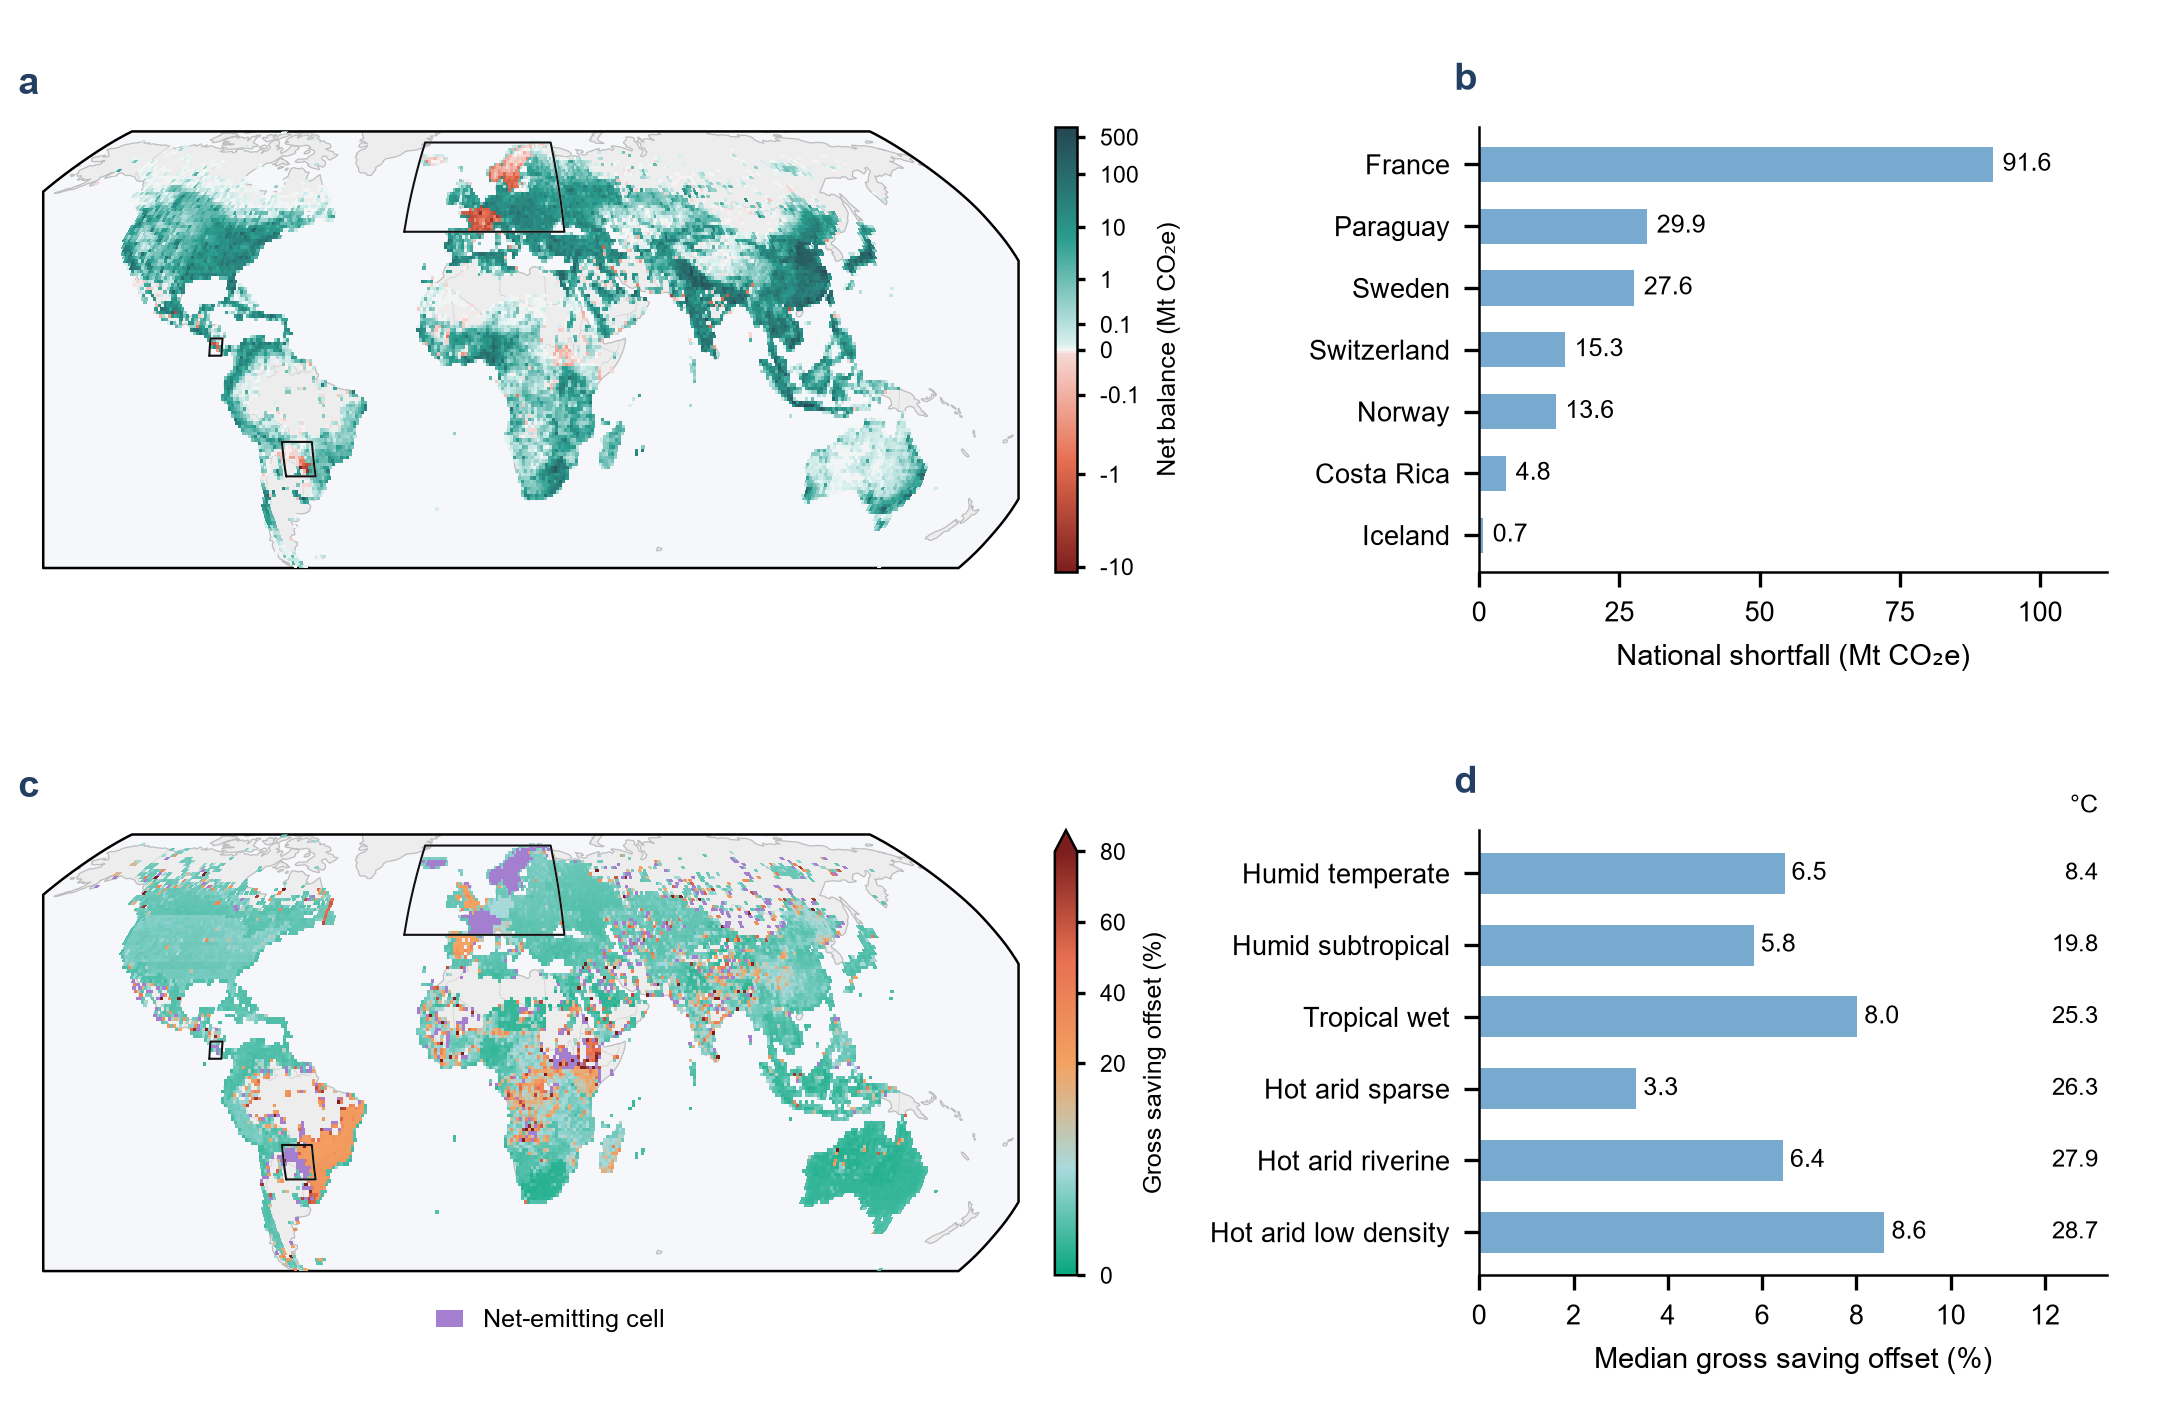

In [6]:
reset_plot_style()
fig1()
show_figure(1)


## Figure 2

FIGURE 2 EXPORTED


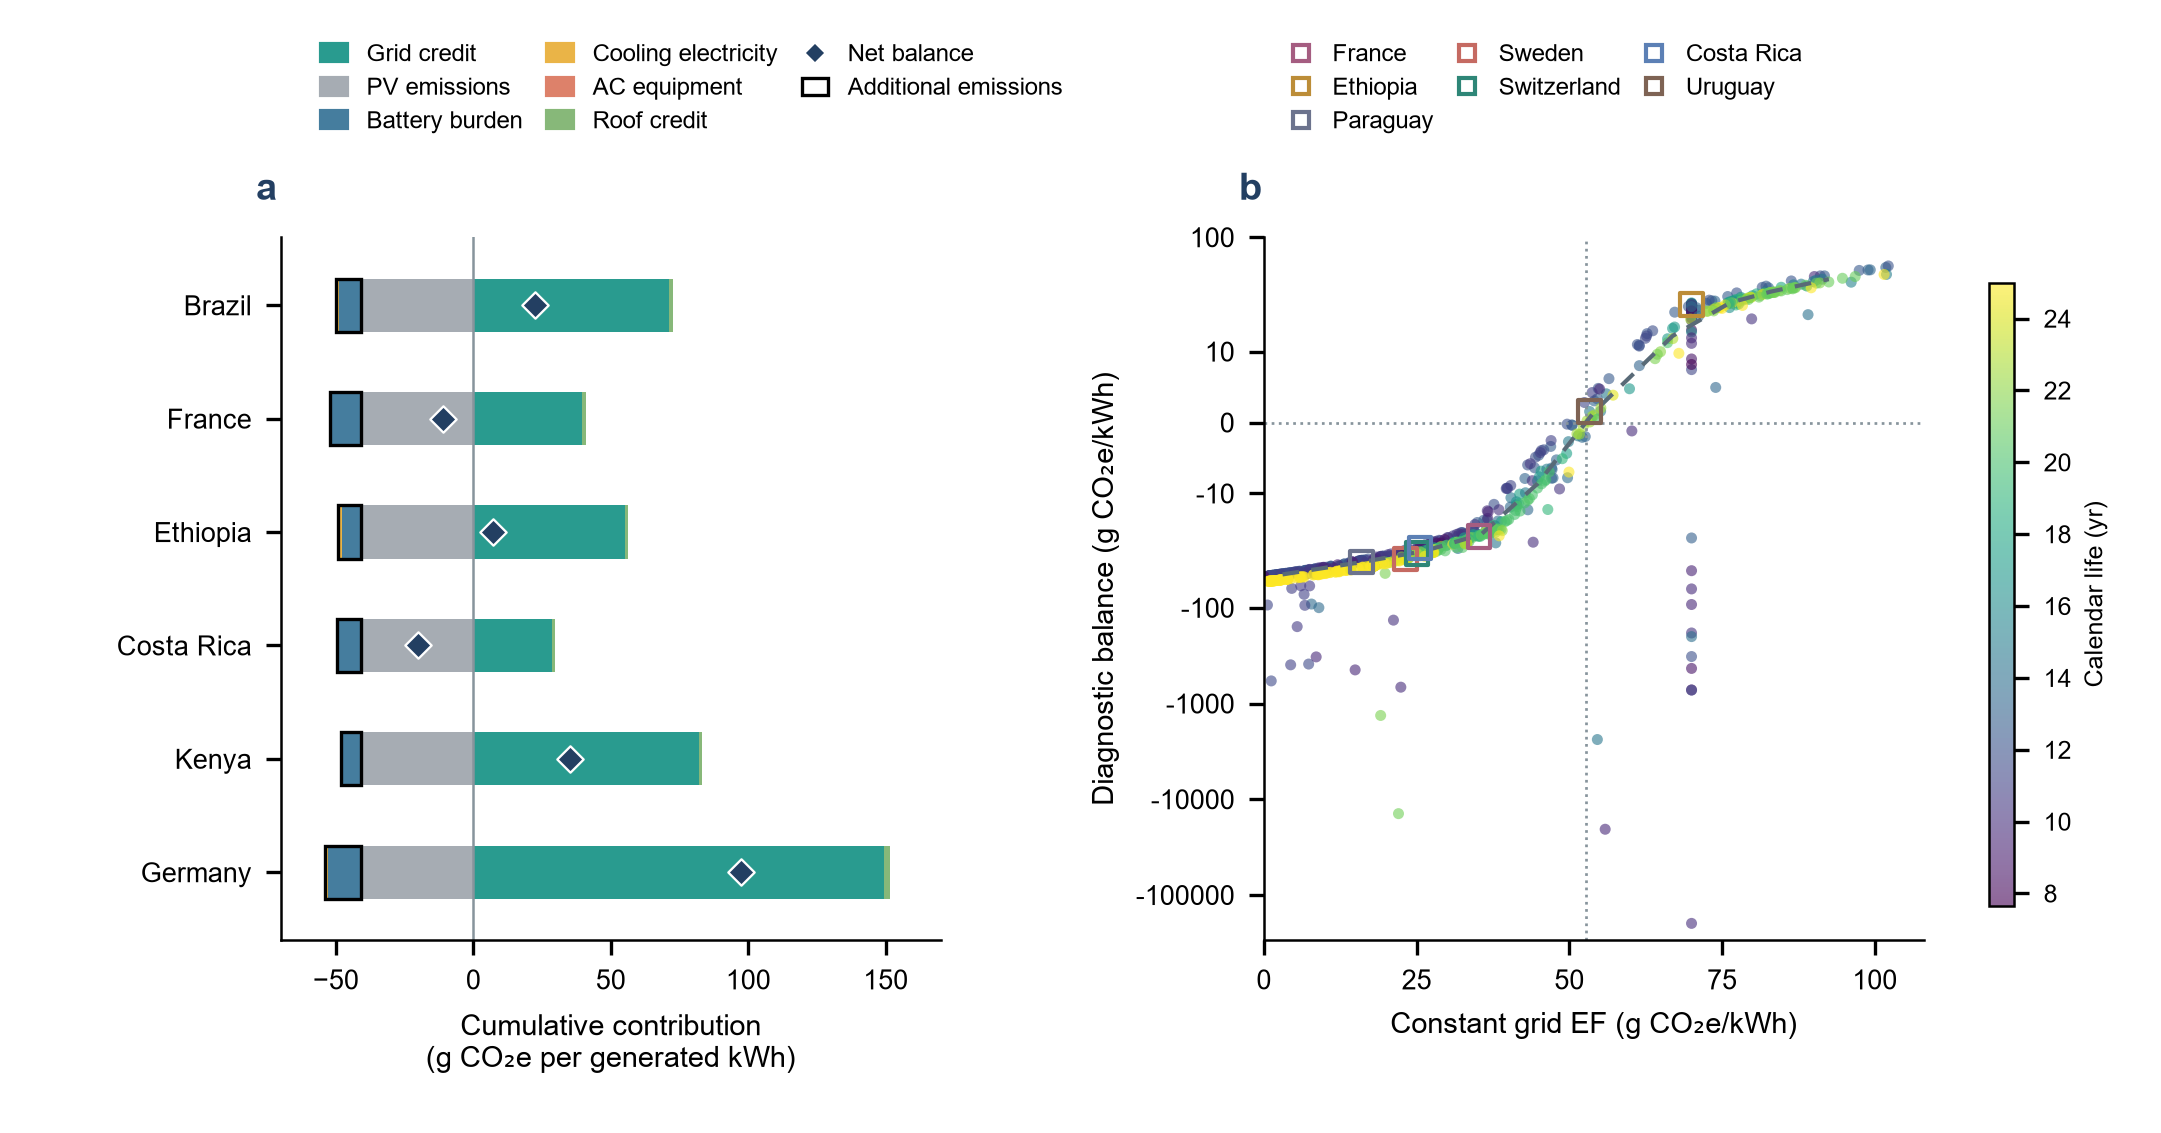

In [7]:
reset_plot_style()
from pathlib import Path
import sys,os,json
R=Path(__file__).resolve().parent


os.environ['MPLCONFIGDIR']=str(WORK/'matplotlib')
import numpy as np
import pandas as pd
import matplotlib as mpl
mpl.use('Agg')
import matplotlib.pyplot as plt
from matplotlib.patches import Patch,Rectangle
from matplotlib.lines import Line2D
from matplotlib.ticker import FuncFormatter
checks={}
INK='#233F62';POS='#267EB2';NEG='#B44843';TEAL='#299B8F';GREY='#87949C'
mpl.rcParams.update({'font.family':['Arial','DejaVu Sans'],'font.size':7,'axes.labelsize':7,'xtick.labelsize':6.5,'ytick.labelsize':6.5,'legend.fontsize':6,'axes.spines.top':False,'axes.spines.right':False,'axes.linewidth':.6,'svg.fonttype':'none','pdf.fonttype':42,'savefig.facecolor':'white'})
def name(s):
    return {'uk':'UK','usa':'USA','row':'Rest of world'}.get(s,s.replace('_',' ').title())

def panel(ax,letter,title=None):
    ax.set_label(letter)
    ax.annotate(letter,(0,1),xycoords='axes fraction',xytext=(-6,9),textcoords='offset points',fontsize=9,fontweight='bold',color=INK,annotation_clip=False)
    if title:ax.set_title(title,loc='left',fontsize=7.5,pad=15,color=INK)

def export(fig,n,axes=None,**kwargs):
    fig.canvas.draw()
    if axes is not None:kwargs['exclude_axes']=[a for a in fig.axes if a not in axes]
    require_matplotlib_panel_alignment(fig,json_out=str(Q/f'Figure_{n}.alignment.json'),overlay_svg=str(Q/f'Figure_{n}.alignment.svg'),strict=True,tolerance_pt=1.5,gutter_tolerance_pt=1.5,**kwargs)
    fig.savefig(O/f'Figure_{n}.pdf',dpi=600)
    fig.savefig(O/f'Figure_{n}.svg',dpi=600)
    fig.savefig(O/f'Figure_{n}.png',dpi=300)
    fig.savefig(O/f'Figure_{n}.tiff',dpi=600,pil_kwargs={'compression':'tiff_lzw'})
    plt.close(fig)
    print('FIGURE',n,'EXPORTED',flush=True)

def wq(v,w,q):
    v=np.asarray(v);w=np.asarray(w);order=np.argsort(v);v=v[order];w=w[order]
    assert np.isfinite(v).all() and (w>0).all()
    return v[np.searchsorted(np.cumsum(w),q*w.sum(),side='left')]

def fig2():
    countries=['brazil','france','ethiopia','costa_rica','kenya','germany']
    high=pd.read_csv(D/'country_endpoints.csv').query('final_coverage_pct==75').set_index('country_tag')
    data=high.loc[countries].copy();den=data.cumulative_generation_twh*1e-6
    comps=[('displaced_grid','Grid credit',1,TEAL),('pv_embodied','PV emissions',-1,'#A6ACB3'),('battery','Battery burden',-1,'#457D9E'),('cooling','Cooling electricity',-1,'#EAB447'),('ac','AC equipment',-1,'#DD816A'),('roof_credit','Roof credit',1,'#87B879')]
    for k,_,sign,_ in comps:data[k+'_g_kwh']=sign*data['cumulative_'+k+'_gt']/den
    data['net_g_kwh']=data.cumulative_net_gt/den
    np.testing.assert_allclose(data[[k+'_g_kwh' for k,_,_,_ in comps]].sum(1),data.net_g_kwh,atol=1e-9)
    data.to_csv(D/'figure2_component_budget.csv')
    cells=pd.read_csv(D/'figure2_diagnostic_cells.csv');pts=cells[cells.main_displayed].copy()
    trend=pd.read_csv(D/'figure2_diagnostic_trend.csv')
    x=trend.ef_g_kwh.to_numpy();y=trend['median'].to_numpy();assert np.all(np.diff(x)>0)
    idx=np.flatnonzero(y[:-1]*y[1:]<0);assert len(idx)==1;i=idx[0]
    crossing=x[i]-y[i]*(x[i+1]-x[i])/(y[i+1]-y[i])
    fig,(a,b)=plt.subplots(1,2,figsize=(7.204724,96/25.4))
    fig.subplots_adjust(left=.13,right=.89,bottom=.17,top=.79,wspace=.49)
    pos=np.zeros(6);neg=np.zeros(6)
    for k,lab,sign,color in comps:
        vals=data[k+'_g_kwh'].to_numpy();left=np.where(vals>=0,pos,neg)
        a.barh(range(6),vals,left=left,color=color,height=.47)
        pos+=np.maximum(vals,0);neg+=np.minimum(vals,0)
    # Outline exactly the three adjacent additional-emission components.
    for j,(_,row) in enumerate(data.iterrows()):
        width=-(row.battery_g_kwh+row.cooling_g_kwh+row.ac_g_kwh)
        right=row.pv_embodied_g_kwh
        a.add_patch(Rectangle((right-width,j-.235),width,.47,facecolor='none',edgecolor='black',linewidth=.8,zorder=6))
    a.scatter(data.net_g_kwh,range(6),marker='D',s=20,c=INK,edgecolors='white',linewidths=.55,zorder=4)
    a.axvline(0,c=GREY,lw=.6);a.set(yticks=range(6),yticklabels=[name(x) for x in countries],ylim=(5.6,-.6),xlim=(-70,170),xticks=[-50,0,50,100,150],xlabel='Cumulative contribution\n(g CO₂e per generated kWh)')
    sc=b.scatter(pts.grid_ef_2050_g_per_kwh,pts.diagnostic_g_kwh,c=pts.battery_life,cmap='viridis',s=7,alpha=.6,edgecolors='none',rasterized=True)
    b.plot(x,y,c='#596A77',lw=1,ls=(0,(4,3)))
    anchor_tags=['france','ethiopia','paraguay','sweden','switzerland','costa_rica','uruguay']
    acols=['#A55D81','#BC8D38','#6C738D','#C56A62','#2E8677','#5C80B5','#7E6354']
    anchors=[];handles=[]
    for tag,col in zip(anchor_tags,acols):
        sub=cells.query('country_tag==@tag');xx=wq(sub.grid_ef_2050_g_per_kwh,sub.cumulative_generation_twh,.5);yy=wq(sub.diagnostic_g_kwh,sub.cumulative_generation_twh,.5)
        b.scatter(xx,yy,marker='s',s=29,facecolors='none',edgecolors=col,linewidths=1,zorder=5)
        handles.append(Line2D([],[],ls='none',marker='s',mfc='none',mec=col,ms=4,label=name(tag)))
        anchors.append(dict(country_tag=tag,ef_g_kwh=xx,net_g_kwh=yy))
    b.set_yscale('symlog',linthresh=15)
    b.set(xlim=(0,108),ylim=(min(-110,pts.diagnostic_g_kwh.min()*1.5),max(100,pts.diagnostic_g_kwh.max()*1.2)),xlabel='Constant grid EF (g CO₂e/kWh)',ylabel='Diagnostic balance (g CO₂e/kWh)',xticks=[0,25,50,75,100])
    b.yaxis.set_major_formatter(FuncFormatter(lambda v,p:f'{v:g}'))
    b.axhline(0,c=GREY,lw=.65,ls=':');b.axvline(crossing,c=GREY,lw=.65,ls=':')
    cax=fig.add_axes([.92,.20,.012,.55]);cb=fig.colorbar(sc,cax=cax);cb.set_label('Calendar life (yr)',fontsize=6,labelpad=3);cb.ax.tick_params(labelsize=6)
    component_handles=[Patch(color=color,label=lab) for _,lab,_,color in comps]+[Line2D([],[],ls='none',marker='D',mfc=INK,mec='white',ms=4,label='Net balance'),Patch(facecolor='none',edgecolor='black',linewidth=.8,label='Additional emissions')]
    fig.legend(handles=component_handles,loc='upper center',bbox_to_anchor=(.32,.98),ncol=3,frameon=False,fontsize=5.8,columnspacing=1.0,labelspacing=.45,handlelength=1.1)
    fig.legend(handles=handles,loc='upper center',bbox_to_anchor=(.715,.98),ncol=3,frameon=False,fontsize=5.8,columnspacing=.9,labelspacing=.45,handlelength=1.0)
    panel(a,'a');panel(b,'b')
    export(fig,2,axes=[a,b])
    pd.DataFrame(anchors).to_csv(D/'figure2_country_anchors.csv',index=False)
    checks['figure2']={'diagnostic_displayed':len(pts),'diagnostic_available':len(cells),'display_rule':'Inherited main_displayed mask, EF <= 105 g/kWh','crossing_g_kwh':crossing,'country_budget_count':6}
fig2()

show_figure(2)


## Figure 3

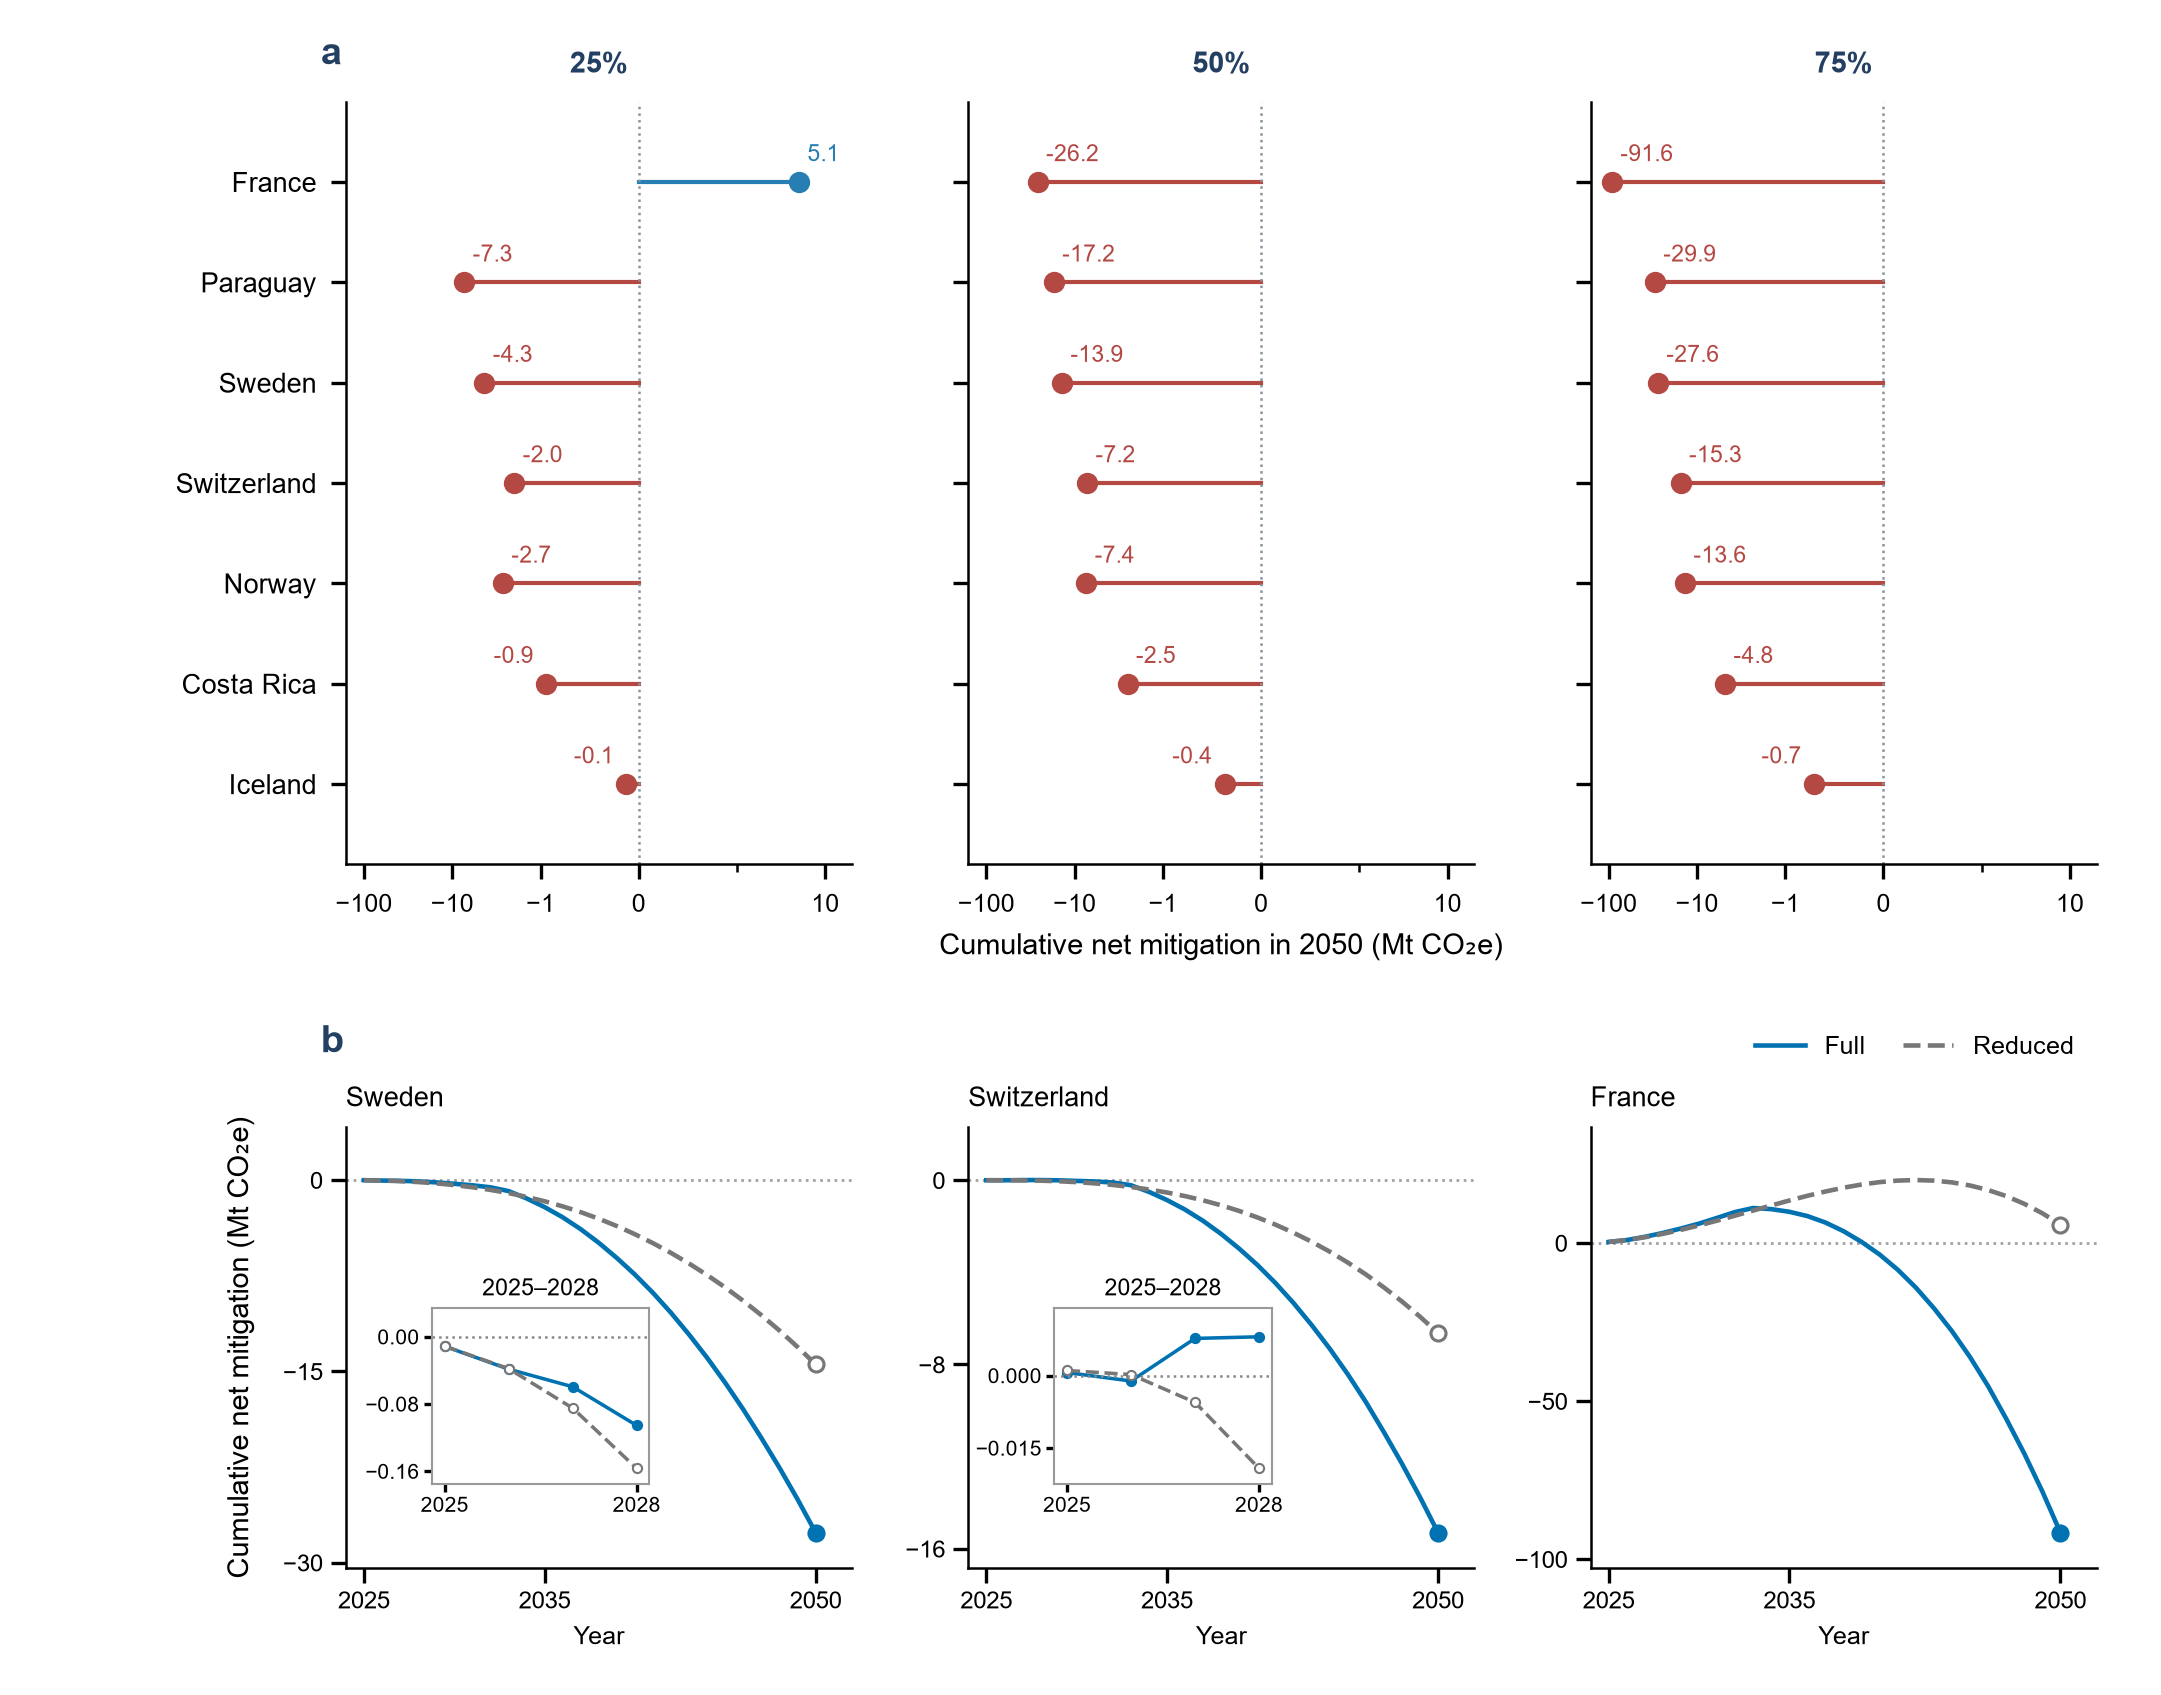

In [8]:
reset_plot_style()
from pathlib import Path
import sys,json
R=Path(__file__).resolve().parent;B=R.parent


D=D
ep=pd.read_csv(D/'country_endpoints.csv')
high=ep.query('final_coverage_pct==75').set_index('country_tag')
tags=high.query('cumulative_net_gt<0').sort_values('cumulative_net_gt').index.tolist()
paths=pd.read_csv(D/'figure3_time_paths.csv')
used=paths[paths.country_tag.isin(tags)].copy()
assert len(used)==7*2*26
for row in used.query("year==2050 and model=='Full'").itertuples():
    assert abs(row.net_gt-high.loc[row.country_tag,'cumulative_net_gt'])<1e-10
fig=plt.figure(figsize=(7.204724,5.65))
top=fig.add_gridspec(1,3,left=.16,right=.97,bottom=.49,top=.94,wspace=.23)
a_axes=[]
for i,cov in enumerate([25,50,75]):
    ax=fig.add_subplot(top[0,i]);ax.set_label('a'+str(i));a_axes.append(ax)
    sub=ep.query('final_coverage_pct==@cov').set_index('country_tag').loc[tags]
    vals=sub.cumulative_net_gt.to_numpy()*1000
    for j,v in enumerate(vals):
        c=POS if v>=0 else NEG
        ax.plot([0,v],[j,j],color=c,lw=1)
        ax.scatter(v,j,s=17,color=c,zorder=3)
        ax.annotate(f'{v:.1f}',(v,j),xytext=(-3 if abs(v)<1 else 2,5),textcoords='offset points',ha='right' if abs(v)<1 else 'left',fontsize=5.6,color=c)
    ax.set_xscale('symlog',linthresh=1)
    ax.set(xlim=(-160,20),xticks=[-100,-10,-1,0,10],ylim=(6.8,-.8),yticks=range(7),yticklabels=[name(t) for t in tags] if i==0 else [])
    ax.set_xticklabels(['−100','−10','−1','0','10'],fontsize=6)
    ax.axvline(0,color=GREY,lw=.6,ls=':')
    ax.set_title(f'{cov}%',fontsize=7,fontweight='bold',pad=7,color=INK)
panel(a_axes[0],'a');a_axes[0].set_label('a0')
fig.text(.565,.437,'Cumulative net mitigation in 2050 (Mt CO₂e)',ha='center',fontsize=7)
bottom=fig.add_gridspec(1,3,left=.16,right=.97,bottom=.075,top=.335,wspace=.23)
case_tags=['sweden','switzerland','france']
b_axes=[]
for i,tag in enumerate(case_tags):
    ax=fig.add_subplot(bottom[0,i]);b_axes.append(ax);ax.set_label('b'+str(i))
    series=used.query('country_tag==@tag')
    for model,col,ls in [('Full','#0072B2','-'),('Reduced','#777777','--')]:
        s=series.query('model==@model').sort_values('year')
        ax.plot(s.year,s.net_gt*1000,color=col,ls=ls,lw=1.1)
        ax.scatter([2050],[s.net_gt.iloc[-1]*1000],s=13,marker='o',facecolors=col if model=='Full' else 'white',edgecolors=col,linewidths=.75,zorder=4)
    vals=series.net_gt*1000;lo=min(0,float(vals.min()));hi=max(0,float(vals.max()));span=hi-lo
    ax.set_ylim(lo-.10*span,hi+.15*span)
    ax.axhline(0,color='#A0A0A0',lw=.65,ls=':',zorder=0)
    ax.set(xlim=(2024,2052),xticks=[2025,2035,2050])
    ax.tick_params(labelsize=5.8,pad=2)
    ax.yaxis.set_major_locator(plt.MaxNLocator(nbins=3))
    ax.set_title(name(tag),fontsize=6.5,loc='left',pad=5)
    ax.set_xlabel('Year',fontsize=6,labelpad=3)
    full=series.query("model=='Full'").sort_values('year')
    if tag!='france':
        ins=ax.inset_axes([.17,.19,.43,.40]);ins.set_label('inset_'+tag)
        early=series[series.year<=2028]
        for model,col,ls in [('Full','#0072B2','-'),('Reduced','#777777','--')]:
            s=early.query('model==@model').sort_values('year')
            ins.plot(s.year,s.net_gt*1000,color=col,ls=ls,lw=.85,marker='o',ms=2.2,mfc=col if model=='Full' else 'white',mec=col,mew=.5)
        vals=early.net_gt*1000;lo=min(0,vals.min());hi=max(0,vals.max());span=hi-lo
        ins.set(xlim=(2024.8,2028.2),ylim=(lo-.12*span,hi+.22*span),xticks=[2025,2028])
        ins.axhline(0,color='#888888',lw=.6,ls=':')
        ins.yaxis.set_major_locator(plt.MaxNLocator(nbins=3))
        ins.tick_params(labelsize=5,pad=1,length=2)
        ins.set_title('2025–2028',fontsize=5.5,pad=3)
        for spine in ins.spines.values():spine.set_visible(True);spine.set_color('#999999');spine.set_linewidth(.5)
panel(b_axes[0],'b');b_axes[0].set_label('b0')
for text in b_axes[0].texts:
    if text.get_text()=='b':text.set_position((-6,18))
fig.text(.105,.205,'Cumulative net mitigation (Mt CO₂e)',rotation=90,va='center',fontsize=7)
handles=[Line2D([],[],color='#0072B2',lw=1.1,label='Full'),Line2D([],[],color='#777777',ls='--',lw=1.1,label='Reduced')]
fig.legend(handles=handles,loc='center right',bbox_to_anchor=(.97,.382),ncol=2,frameon=False,fontsize=6,handlelength=2,columnspacing=1.5)
fig.canvas.draw()
require_matplotlib_panel_alignment(fig,json_out=str(Q/'alignment.json'),strict=True,tolerance_pt=1.5)
for ext,dpi in [('png',300),('pdf',600),('svg',600),('tiff',600)]:
    kw={'pil_kwargs':{'compression':'tiff_lzw'}} if ext=='tiff' else {}
    fig.savefig(O/f'Figure_3.{ext}',dpi=dpi,**kw)
plt.close(fig)
used[used.country_tag.isin(case_tags)].to_csv(O/'figure3_displayed_paths.csv',index=False)
(Q/'data_check.json').write_text(json.dumps({'countries':tags,'rows':len(used),'units':'net_gt multiplied by 1000 to Mt CO2e','endpoint_check':'all Full 2050 endpoints match panel a at 75%','independent_y_scales':True},indent=2))




show_figure(3)


## Figure 4

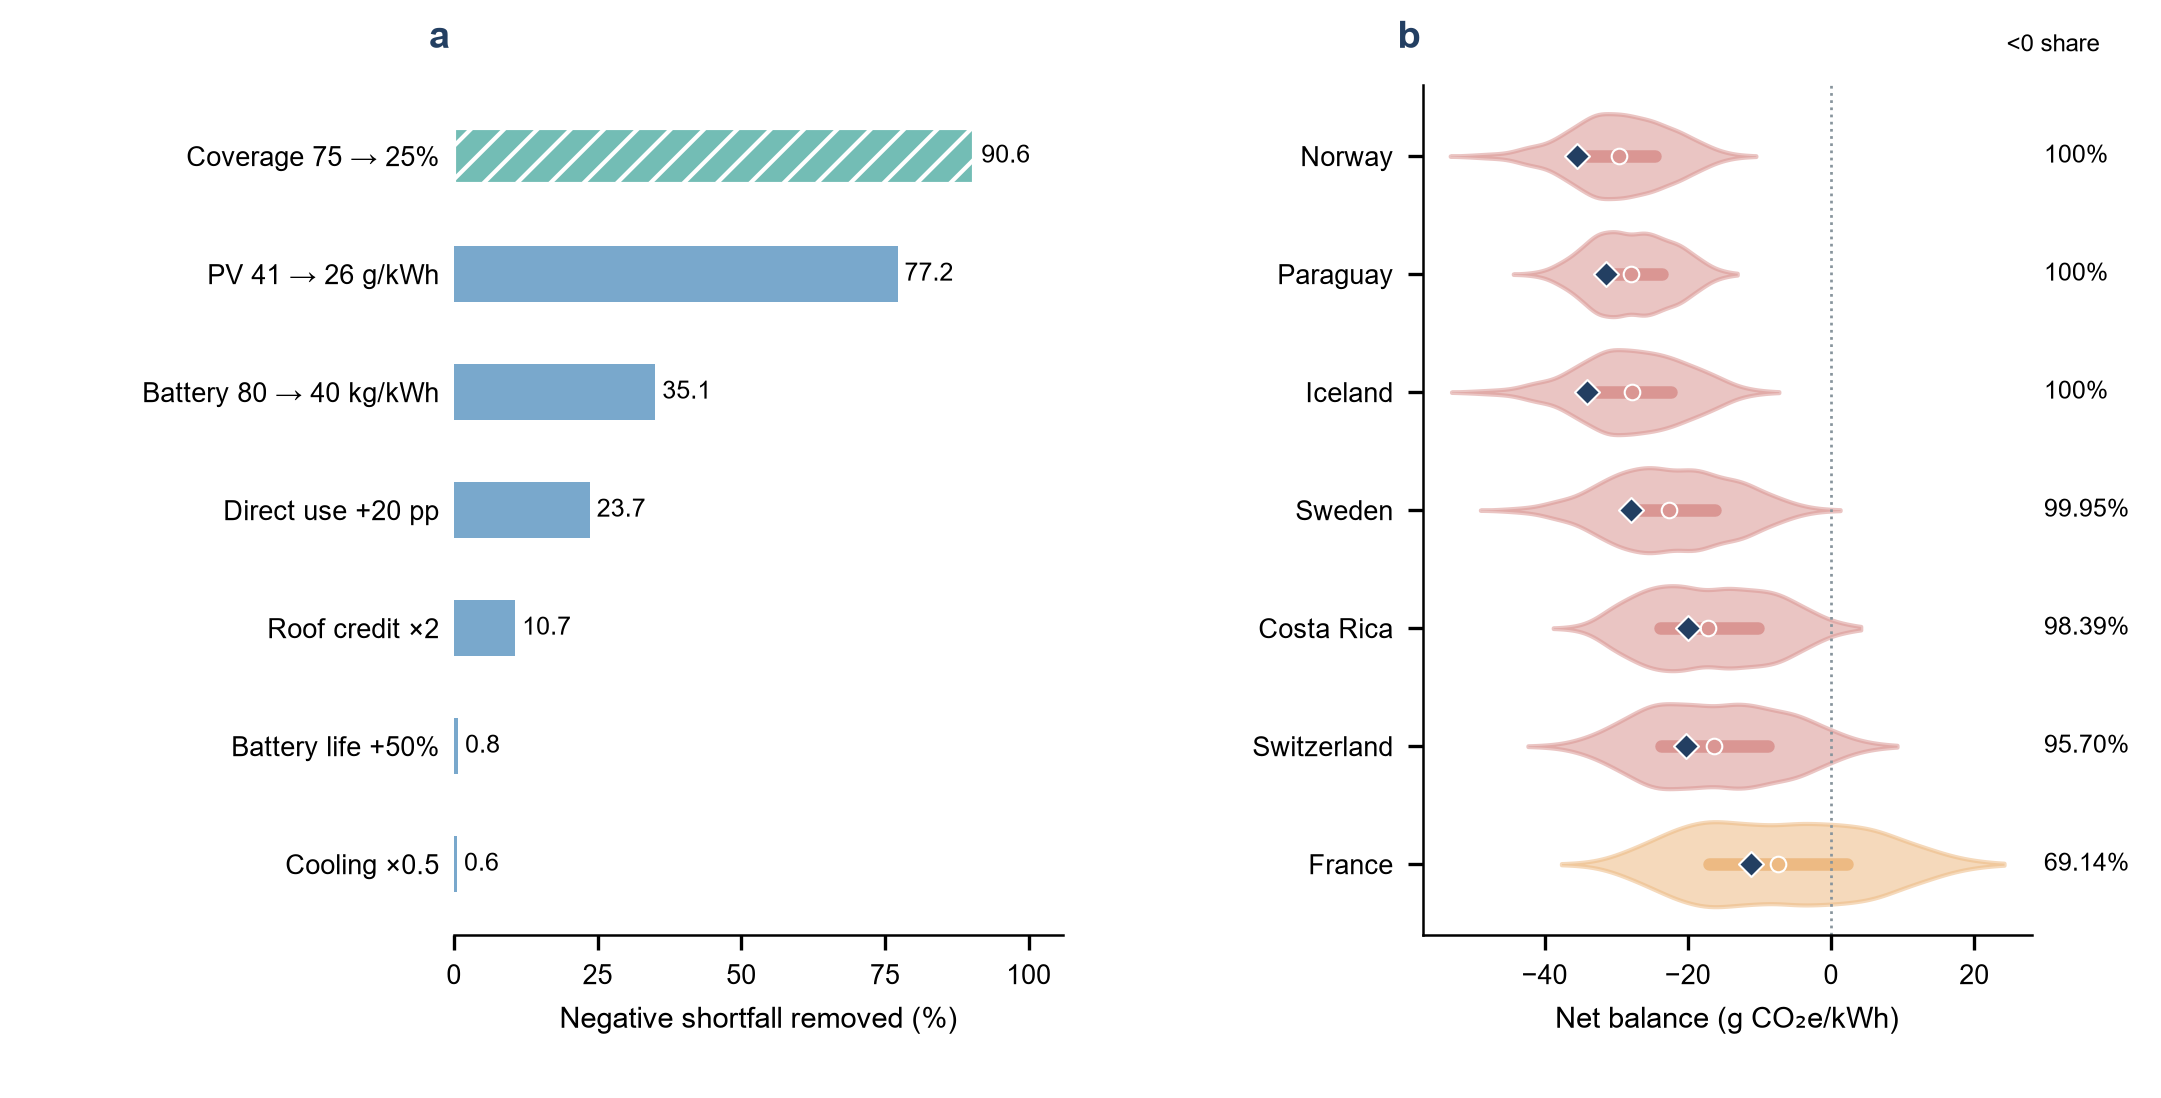

In [9]:
reset_plot_style()
from pathlib import Path
import sys
R=Path(__file__).resolve().parent;B=R.parent

from matplotlib.transforms import Bbox

D=D
def export(fig,n,**kwargs):
    a=fig.axes[0]
    a.set_yticklabels([t.get_text().replace('%*','%') for t in a.get_yticklabels()])
    fig.canvas.draw()
    require_matplotlib_panel_alignment(fig,json_out=str(Q/'alignment.json'),strict=True,tolerance_pt=1.5)
    bbox=Bbox.from_extents(0,8/25.4,fig.get_figwidth(),fig.get_figheight()-8/25.4)
    for ext,dpi in [('pdf',600),('svg',600),('png',300),('tiff',600)]:
        kw={'pil_kwargs':{'compression':'tiff_lzw'}} if ext=='tiff' else {}
        fig.savefig(O/f'Figure_4.{ext}',dpi=dpi,bbox_inches=bbox,**kw)
    plt.close(fig)
export=export
fig4()

show_figure(4)


## Figure 5

Figure 5 exported.


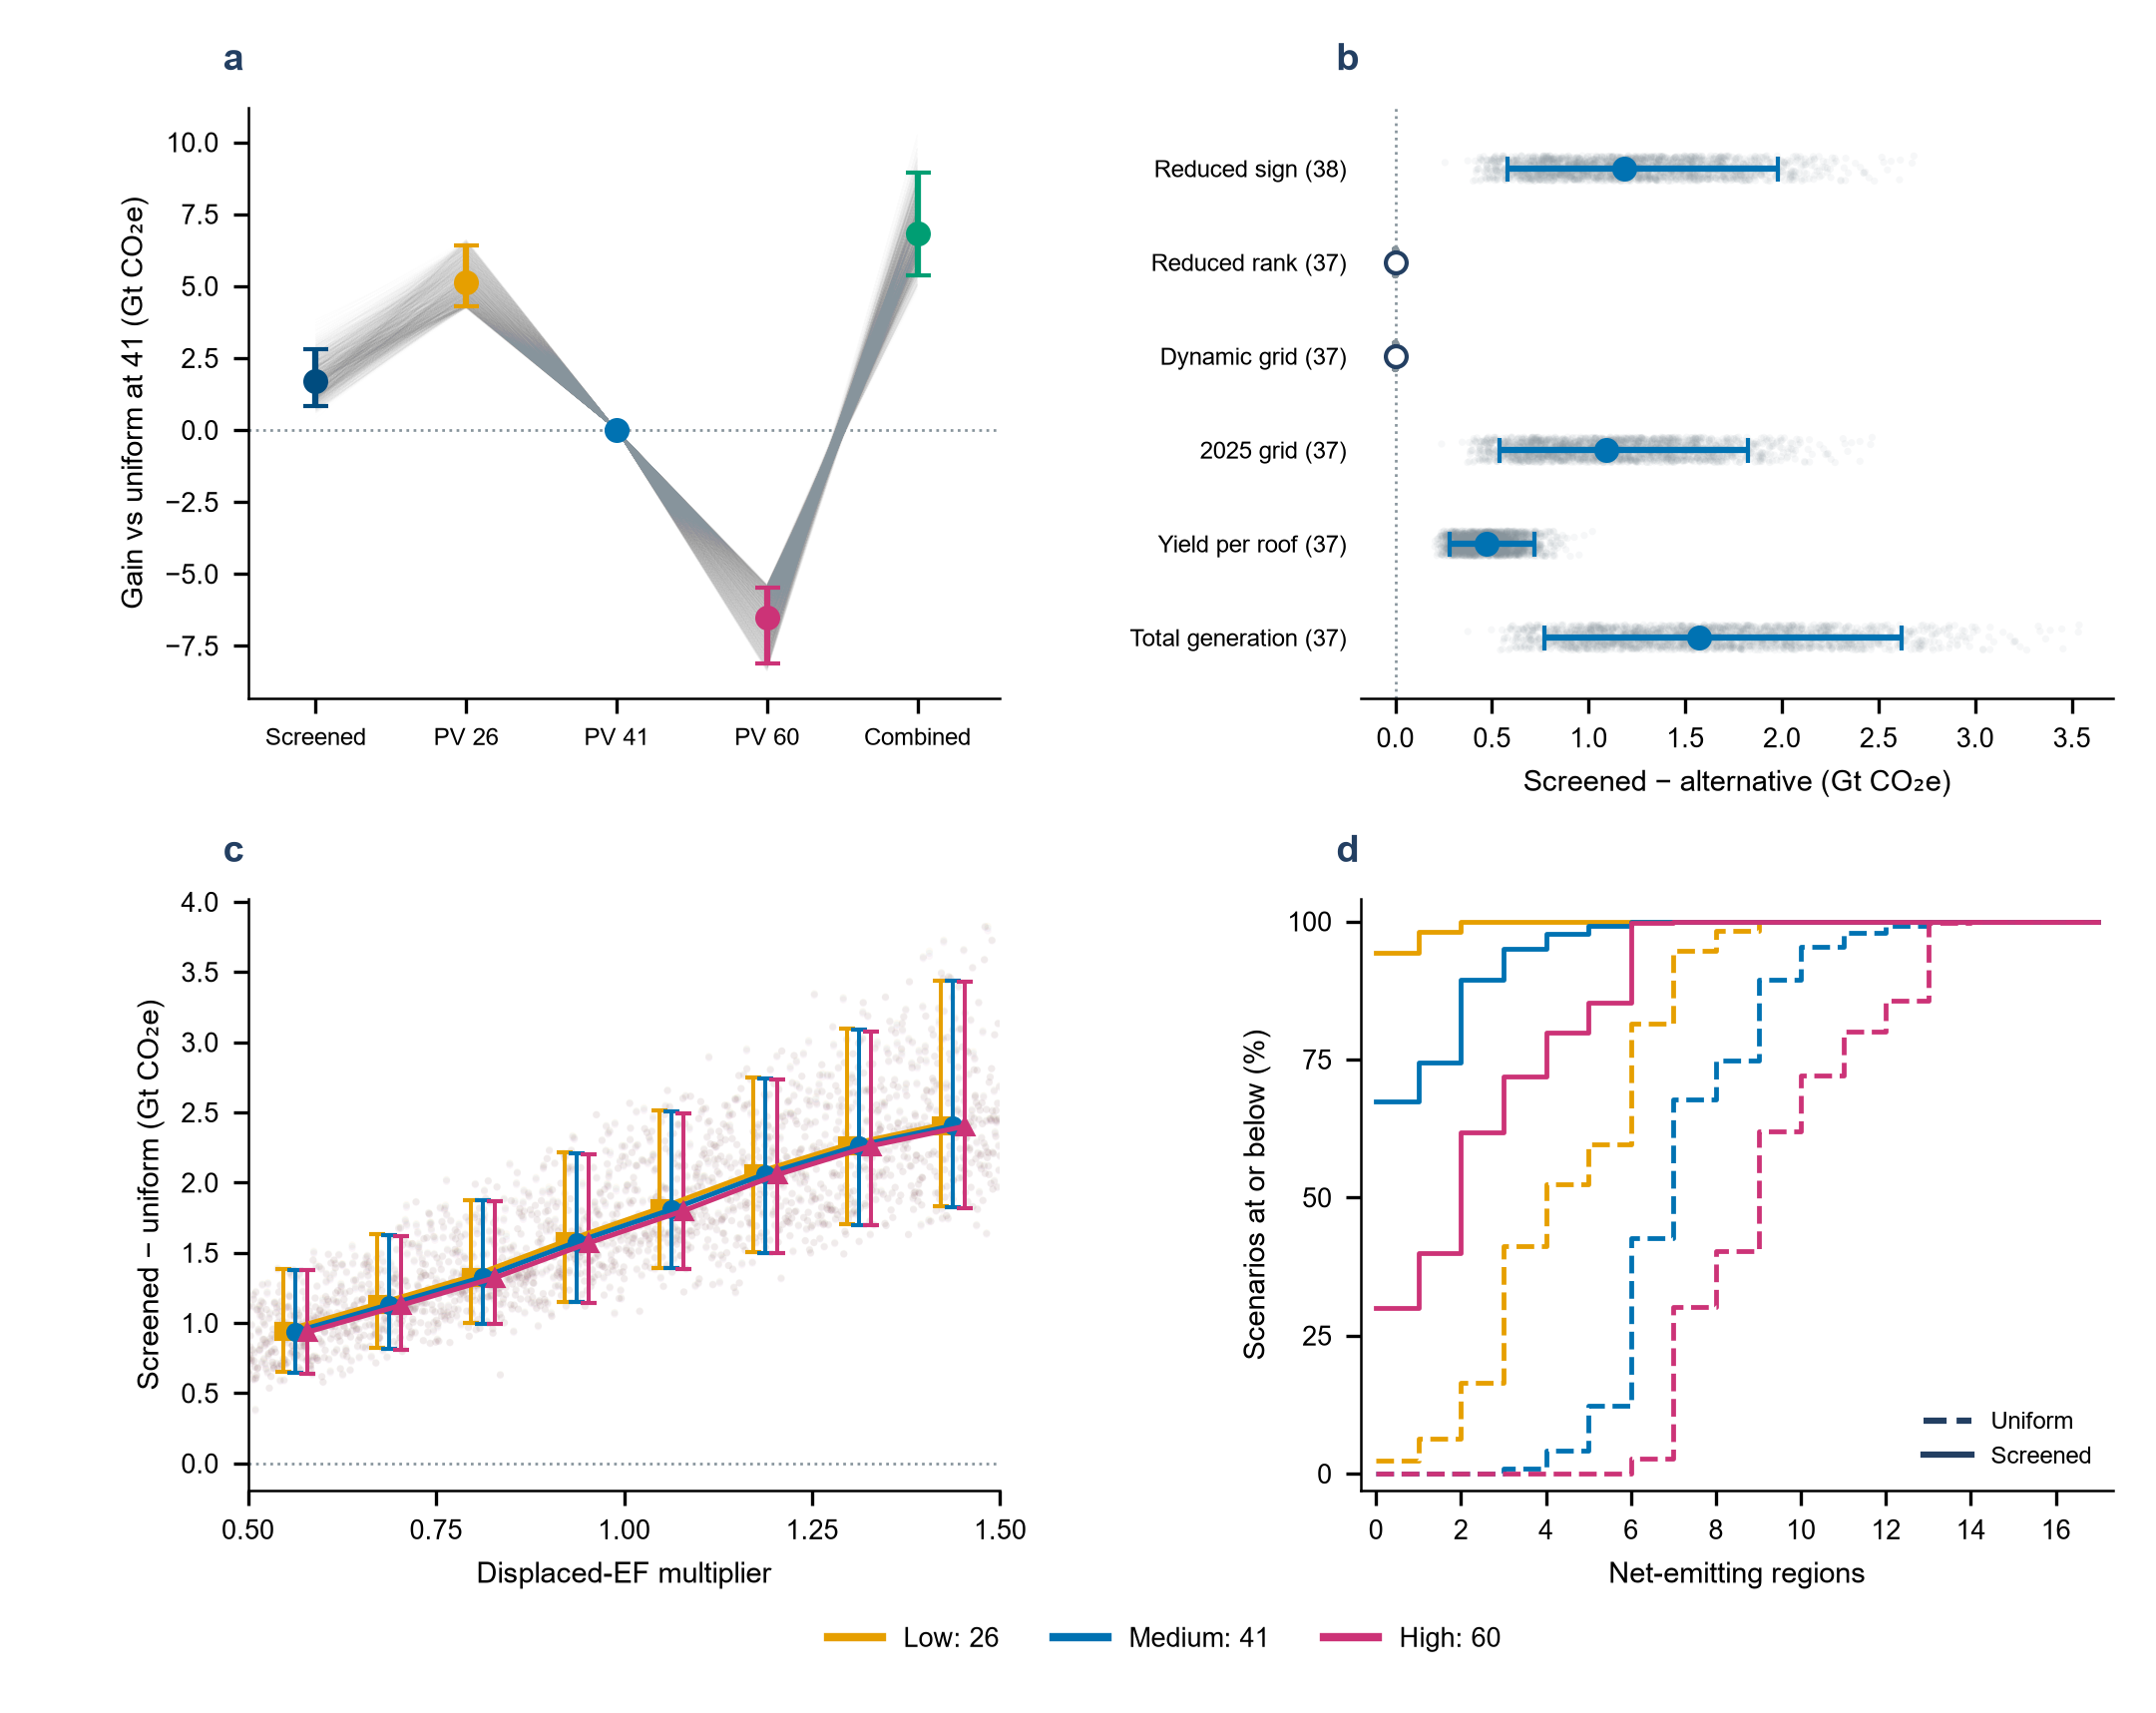

In [10]:
reset_plot_style()
from pathlib import Path
import sys,json
R=Path(__file__).resolve().parent;B=R.parent


from matplotlib.transforms import Bbox
POS='#0072B2';TEAL='#E69F00';NEG='#CC3377';INK='#233F62'
def export(fig,n,**kwargs):
    fig.canvas.draw()
    require_matplotlib_panel_alignment(fig,json_out=str(Q/'Figure_5.alignment.json'),strict=True,tolerance_pt=1.5)
    bbox=Bbox.from_extents(0,7/25.4,fig.get_figwidth(),fig.get_figheight())
    for ext,dpi in [('pdf',600),('svg',600),('png',300),('tiff',600)]:
        kw={'pil_kwargs':{'compression':'tiff_lzw'}} if ext=='tiff' else {}
        fig.savefig(O/f'Figure_5.{ext}',dpi=dpi,bbox_inches=bbox,**kw)
    plt.close(fig)
export=export

"""Joint deployment and literature-envelope comparison, all paired scenarios."""

def draw():
    totals=pd.read_csv(D/'figure5_lmh_totals.csv').query('sample_id>0')
    p=pd.read_csv(D/'scenario_parameters.csv').query('sample_id>0').set_index('sample_id')
    rules=pd.read_csv(D/'figure5_rule_results.csv').query('sample_id>0')
    assert len(totals)==2048*6 and rules.feasible.all()
    colors={26:TEAL,41:POS,60:NEG}
    fig,axes=plt.subplots(2,2,figsize=(7.2047,6.0))
    fig.subplots_adjust(left=.115,right=.98,bottom=.17,top=.94,hspace=.34,wspace=.48)
    a,b,c,d=axes.ravel();stats=[]
    categories=[('Screened','Screened',41,'#004C7F'),('PV 26','Uniform',26,TEAL),('PV 41','Uniform',41,POS),('PV 60','Uniform',60,NEG),('Combined','Screened',26,'#009E73')]
    paired=pd.DataFrame({label:totals.query('strategy==@strategy and pv_factor==@factor').set_index('sample_id').gain_gt for label,strategy,factor,color in categories}).sort_index()
    assert paired.shape==(2048,5) and paired.notna().all().all()
    segments=np.stack([np.tile(np.arange(5),(2048,1)),paired.to_numpy()],axis=2)
    a.add_collection(LineCollection(segments,colors=GREY,alpha=.006,linewidths=.25,rasterized=True))
    for x,(label,strategy,factor,color) in enumerate(categories):
        q=qsummary(paired[label])
        a.errorbar(x,q[2],yerr=[[q[2]-q[0]],[q[4]-q[2]]],fmt='o',color=color,ms=5,capsize=3,elinewidth=1.5,zorder=4)
        stats.append(dict(category=label,strategy=strategy,pv_factor=factor,p05=q[0],median=q[2],p95=q[4]))
    paired.to_csv(D/'figure5a_paired_categories.csv')
    a.axhline(0,color=GREY,lw=.65,ls=':')
    a.autoscale_view();a.set(xticks=range(5),xticklabels=[x[0] for x in categories],xlim=(-.45,4.55),ylabel='Gain vs uniform at 41 (Gt CO₂e)')
    a.tick_params(axis='x',labelsize=5.8)
    full=rules.query('rule=="FullSign"').set_index('sample_id').sort_index()
    ruleorder=['ReducedSign','ReducedTopK','GridDynamicTopK','Grid2025TopK','YieldTopK','TotalPVTopK']
    labs=['Reduced sign (38)','Reduced rank (37)','Dynamic grid (37)','2025 grid (37)','Yield per roof (37)','Total generation (37)']
    comp=[]
    for j,(rule,lab) in enumerate(zip(ruleorder,labs)):
        sub=rules.query('rule==@rule').set_index('sample_id').loc[full.index]
        vals=full.net_gt.to_numpy()-sub.net_gt.to_numpy();jitter=((full.index.to_numpy()*37)%101/100-.5)*.27
        b.scatter(vals,j+jitter,s=3,c=GREY,alpha=.07,edgecolors='none',rasterized=True)
        q=qsummary(vals);tie=np.max(abs(vals))<1e-8
        b.errorbar(q[2],j,xerr=[[q[2]-q[0]],[q[4]-q[2]]],fmt='o',color=INK if tie else POS,mfc='white' if tie else POS,ms=5,capsize=3,elinewidth=1.5,zorder=4)
        comp.append(dict(rule=rule,p05=q[0],median=q[2],p95=q[4],wins=int((vals>1e-8).sum()),ties=int((abs(vals)<=1e-8).sum()),losses=int((vals< -1e-8).sum())))
    b.axvline(0,c=GREY,lw=.65,ls=':');b.set(yticks=range(6),yticklabels=labs,ylim=(5.65,-.65),xlabel='Screened − alternative (Gt CO₂e)');b.tick_params(axis='y',labelsize=5.8,length=0);b.spines['left'].set_visible(False)
    bins=np.linspace(.5,1.5,9);br=[];within=[]
    for fi,factor in enumerate([26,41,60]):
        paired=totals.query('pv_factor==@factor').pivot(index='sample_id',columns='strategy',values='net_gt').sort_index()
        advantage=paired.Screened-paired.Uniform;xx=p.loc[paired.index,'displaced_ef_multiplier']
        c.scatter(xx,advantage,s=3,c=colors[factor],alpha=.045,edgecolors='none',rasterized=True)
        for sid,gain in advantage.items():within.append(dict(sample_id=int(sid),pv_factor=factor,screening_gain_gt=gain))
        local=[]
        for k,(lo,hi) in enumerate(zip(bins[:-1],bins[1:])):
            mask=(xx>=lo)&(xx<hi if k<7 else xx<=hi);assert mask.sum()>0
            q=qsummary(advantage[mask]);local.append(dict(pv_factor=factor,center=(lo+hi)/2,p05=q[0],median=q[2],p95=q[4],n=int(mask.sum())))
        summary=pd.DataFrame(local);br.extend(local)
        c.errorbar(summary.center+(fi-1)*.016,summary['median'],yerr=[summary['median']-summary.p05,summary.p95-summary['median']],fmt=['s-','o-','^-'][fi],color=colors[factor],lw=1.2,ms=3.6,capsize=2,elinewidth=.95,label=f'{factor}')
    c.axhline(0,c=GREY,lw=.65,ls=':');c.set(xlim=(.5,1.5),xticks=[.5,.75,1,1.25,1.5],xlabel='Displaced-EF multiplier',ylabel='Screened − uniform (Gt CO₂e)')
    maximum=int(totals.negative_regions.max());dist=[]
    for factor in [26,41,60]:
        for strategy in ['Uniform','Screened']:
            counts=totals.query('pv_factor==@factor and strategy==@strategy').negative_regions.to_numpy(int)
            xs=np.arange(maximum+1);ys=np.array([(counts<=x).mean()*100 for x in xs])
            d.step(xs,ys,where='post',color=colors[factor],ls='--' if strategy=='Uniform' else '-',lw=1.15)
            dist.extend(dict(pv_factor=factor,strategy=strategy,count=int(x),share_pct=float(y)) for x,y in zip(xs,ys))
    d.set(xlabel='Net-emitting regions',ylabel='Scenarios at or below (%)',xlim=(-.35,maximum+.35),ylim=(-3,104),yticks=[0,25,50,75,100],xticks=np.arange(0,maximum+1,2))
    d.legend(handles=[Line2D([],[],color=INK,ls='--',label='Uniform'),Line2D([],[],color=INK,ls='-',label='Screened')],loc='lower right',fontsize=5.8,frameon=False)
    for ax,lab in zip(axes.ravel(),'abcd'):panel(ax,lab)
    fig.legend(handles=[Line2D([],[],color=colors[f],lw=2,label=f'{level}: {f}') for f,level in [(26,'Low'),(41,'Medium'),(60,'High')]],loc='lower center',bbox_to_anchor=(.54,.066),ncol=3,frameon=False,fontsize=6.5)
    export(fig,5)
    pd.DataFrame(stats).to_csv(D/'figure5_lmh_gain_quantiles.csv',index=False)
    pd.DataFrame(comp).to_csv(D/'figure5_rule_comparison_quantiles.csv',index=False)
    pd.DataFrame(br).to_csv(D/'figure5_lmh_displacement_bins.csv',index=False)
    pd.DataFrame(dist).to_csv(D/'figure5_lmh_risk_cdf.csv',index=False)
    pd.DataFrame(within).to_csv(D/'figure5_lmh_within_factor_gains.csv',index=False)
    return dict(scenarios_per_combination=2048,records=len(totals),rules=comp,gain_quantiles=stats,retained_full=37,reference_factor=41,scenario_factors=[26,41,60])

stats=draw()
(Q/'data_checks.json').write_text(json.dumps(stats,indent=2),encoding='utf8')
print('Figure 5 exported.')

show_figure(5)


## Plotting data

In [11]:
from export_main_data import main as export_plot_data
export_plot_data()


Exported 20 plotting-data tables.
